In [1]:
import sys
from pathlib import Path

# put src/ on the path — this notebook lives in src/analysis_notebooks/
SRC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'params.py').exists())
sys.path.insert(0, str(SRC))
import utils
import params

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_absolute_error
import os
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression, Lasso
from statsmodels import api as sm
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

from pathlib import Path
# Initialize the scaler
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings("ignore")

from matplotlib import pyplot
pyplot.rcParams['figure.dpi'] = 300
pyplot.rcParams['savefig.dpi'] = 600

In [2]:

def deleting_itu_func(data,outcome_var,indicator,CIS_control=False):
    """
    Function to filter and preprocess data by removing ITU-related entries.
    
    Args:
        data (pd.DataFrame): Input dataset.
        outcome_var (str): Target variable for the model.
        indicator (str): Indicator variable (e.g., 'internet', 'mobile').
        CIS_control (bool): Whether to apply specific rules for CIS countries.

    Returns:
        pd.DataFrame: Processed dataset with ITU-related entries removed.

    """
    data = data.loc[~data['iso3'].isin(params.sanction_countries)]
    if CIS_control:
        for iso3 in data.iso3.unique():
            if iso3 in CIS_countries:
                if ('itu' in data.loc[data['iso3']==iso3,f'{indicator}_survey_type'].values) & (data.loc[data['iso3']==iso3,f'{indicator}_survey_type'].nunique()==1):
                        continue
                        #print('CIS',iso3),
                        #print(iso3,data.loc[data['iso3']==iso3,f'{outcome_var}'].values),
                        #survey_values = [x if x>0.8 else None for x in data.loc[data['iso3']==iso3,f'{outcome_var}'].values],
                        #data.loc[data['iso3']==iso3,f'{outcome_var}']= survey_values,
                        #print(data.loc[data['iso3']==iso3,f'{outcome_var}'].values),
                    
                else:
                    data.loc[data['iso3']==iso3,f'{outcome_var}']=[x if y!='itu' else None for x,y in zip(data.loc[data['iso3']==iso3,f'{outcome_var}'],data.loc[data['iso3']==iso3,f'{indicator}_survey_type'])]
            
            elif data.loc[data['iso3']==iso3,'conti'].values[0] in ['Europe','North America','South America']:
                if ('itu' in data.loc[data['iso3']==iso3,f'{indicator}_survey_type'].values) & (data.loc[data['iso3']==iso3,f'{indicator}_survey_type'].nunique()==1):
                    
                    #survey_values = [x if y>0.85 else None for x,y in zip(data.loc[data['iso3']==iso3,f'{outcome_var}'],data.loc[data['iso3']==iso3,f'internet_wom'])]
                    survey_values = [x if y>0.85 else None for x,y in zip(data.loc[data['iso3']==iso3,f'{outcome_var}'],data.loc[data['iso3']==iso3,f'{indicator}_wom'])]
                    data.loc[data['iso3']==iso3,f'{outcome_var}']=  survey_values
                    #print(data.loc[data['iso3']==iso3,f'{outcome_var}'].values),
                else:
                    data.loc[data['iso3']==iso3,f'{outcome_var}']=[x if y!='itu' else None for x,y in zip(data.loc[data['iso3']==iso3,f'{outcome_var}'],data.loc[data['iso3']==iso3,f'{indicator}_survey_type'])]
            else:
                data.loc[data['iso3']==iso3,f'{outcome_var}']=[x if y!='itu' else None for x,y in zip(data.loc[data['iso3']==iso3,f'{outcome_var}'],data.loc[data['iso3']==iso3,f'{indicator}_survey_type'])]

    else:
        data = data.loc[data[f'{indicator}_survey_type']!='itu']
    return data





# 01 extremely small (or negative predictions)

## check the YEM model params and predictions 

In [3]:
indicator = "internet"

data_path = params.dropbox_data_path / f"combined_data/updated_ground_truth_and_fb/{indicator}"
data_path

PosixPath('/Users/valler/Python/RA/Gender_Inequality/dgg_national/data/external/national/data_refresh/new_national_pipeline_files/data/combined_data/updated_ground_truth_and_fb/internet')

In [4]:
# load data 

# Define a list of CIS countries
CIS_countries = params.CIS_countries


for indicator in ['internet','mobile']:
    data_path = params.dropbox_data_path / f"combined_data/updated_ground_truth_and_fb/{indicator}"
    data = pd.read_csv(data_path / f"combined_multiple_years_no_missing_keep_countries_fb_aligned.csv")
    data = deleting_itu_func(data, f'{indicator}_ggi', indicator,True)
    print(f'{indicator}_ggi: {data[f"{indicator}_ggi"].notnull().sum()} samples left for modelling')
    data = data.dropna(subset=[f'{indicator}_ggi'])
    data.to_csv(data_path / f"combined_multiple_years_no_missing_keep_countries_fb_aligned_itu_deleted.csv",index=False)

internet_ggi: 108 samples left for modelling
mobile_ggi: 99 samples left for modelling


In [5]:
len(data)

99

In [6]:
# prepare to check YEM 

data_yem = data.loc[data['iso3'].isin(['YEM','TCD']),['iso3',"fb_18_999_men","fb_18_999_wom","fb_18_999_r",'hdi','gdi','gdp_pcap']]
data_yem['const'] =1 
data_yem['year']=2025-2015

In [7]:

# load model to see the indicators 
df_model_params = pd.DataFrame()
model_type = 'combined_with_CIS'
deleting_itu = True
for indicator in ['internet','mobile']:
    for outcome_var in [f'{indicator}_ggi', f'{indicator}_wom', f'{indicator}_men']:
        model_filename = f'{indicator}_{model_type}_{outcome_var}_full_model.pkl' if deleting_itu else f'{indicator}_{model_type}_{outcome_var.replace(f"{indicator}_", "")}_{outcome_var}_full_model.pkl'
        model_filepath = params.dropbox_data_path.parent / f'models/OLS' / model_filename
        model = utils.load_model(model_filepath)
        df_model_params = pd.concat([df_model_params, pd.DataFrame(model.params).T], axis=0)
        df_model_params.reset_index(drop=True, inplace=True)
        df_model_params.loc[df_model_params.index[-1],'model'] = outcome_var

# compute YEM prediction
model_spec = model.params.index.tolist()
df_model_params['result_yem'] = [data_yem.loc[data_yem['iso3']=='YEM',model_spec].dot(df_model_params.loc[df_model_params['model']==x,model_spec].values[0]).values[0] for x in df_model_params['model']]
df_model_params['result_tcd'] = [data_yem.loc[data_yem['iso3']=='TCD',model_spec].dot(df_model_params.loc[df_model_params['model']==x,model_spec].values[0]).values[0] for x in df_model_params['model']]

# select relevant columns
df_model_params = df_model_params[['result_tcd','result_yem','const', 'fb_18_999_men', 'fb_18_999_wom', 'fb_18_999_r', 'hdi', 'gdi',
       'gdp_pcap', 'year', 'model' ]]
# round values
for col in df_model_params.columns:
    if col != 'model':
        df_model_params[col] = df_model_params[col].round(3)
        

IndexError: index 0 is out of bounds for axis 0 with size 0

In [8]:
df_model_params

,const,fb_18_999_men,fb_18_999_wom,fb_18_999_r,hdi,gdi,gdp_pcap,year,model
0,-1.224587,0.775247,-0.730526,0.506215,0.259207,1.373300,0.004875,0.009162,internet_ggi
1,-1.622419,0.526064,-0.351120,0.122595,0.863617,1.056436,0.035536,0.019753,internet_wom
2,-0.999451,0.722223,-0.568438,0.108297,0.719237,0.524100,0.042296,0.019021,internet_men
3,-0.430609,0.476509,-0.437006,0.297515,0.048698,0.955283,0.012255,0.004278,mobile_ggi
4,-0.863233,0.932848,-0.893437,0.330107,0.034556,0.619352,0.078015,0.006856,mobile_wom
5,0.320481,0.782721,-0.771989,0.174603,0.024395,-0.395446,0.078155,0.004687,mobile_men


## check the predicted values by different thresholds 

In [9]:
# read predictions first 
folder = (params.EXTERNAL / 'pipeline/result')
files = folder.glob('national/*.csv')
df_predictions = pd.concat([pd.read_csv(f) for f in files])
df_predictions.drop(columns=['Unnamed: 0'],inplace=True)

In [10]:
threshold = 0 
df_pred_selected = df_predictions.loc[df_predictions['predicted']<=threshold]

In [11]:
df_pred_selected[['gid_0','outcome']].value_counts().reset_index(name='counts').sort_values(by=['counts'],ascending=[False])

,gid_0,outcome,counts
0,YEM,internet_fm_ratio,87
1,YEM,internet_women,87
2,TCD,internet_women,52
3,NER,internet_women,40
4,AFG,internet_women,31
5,SOM,internet_women,23
6,MLI,internet_women,4
7,CAF,internet_women,3
8,SSD,internet_women,3
9,BDI,internet_women,1


In [12]:
df_data.loc[df_data['iso3'].isin(['YEM'])]

NameError: name 'df_data' is not defined

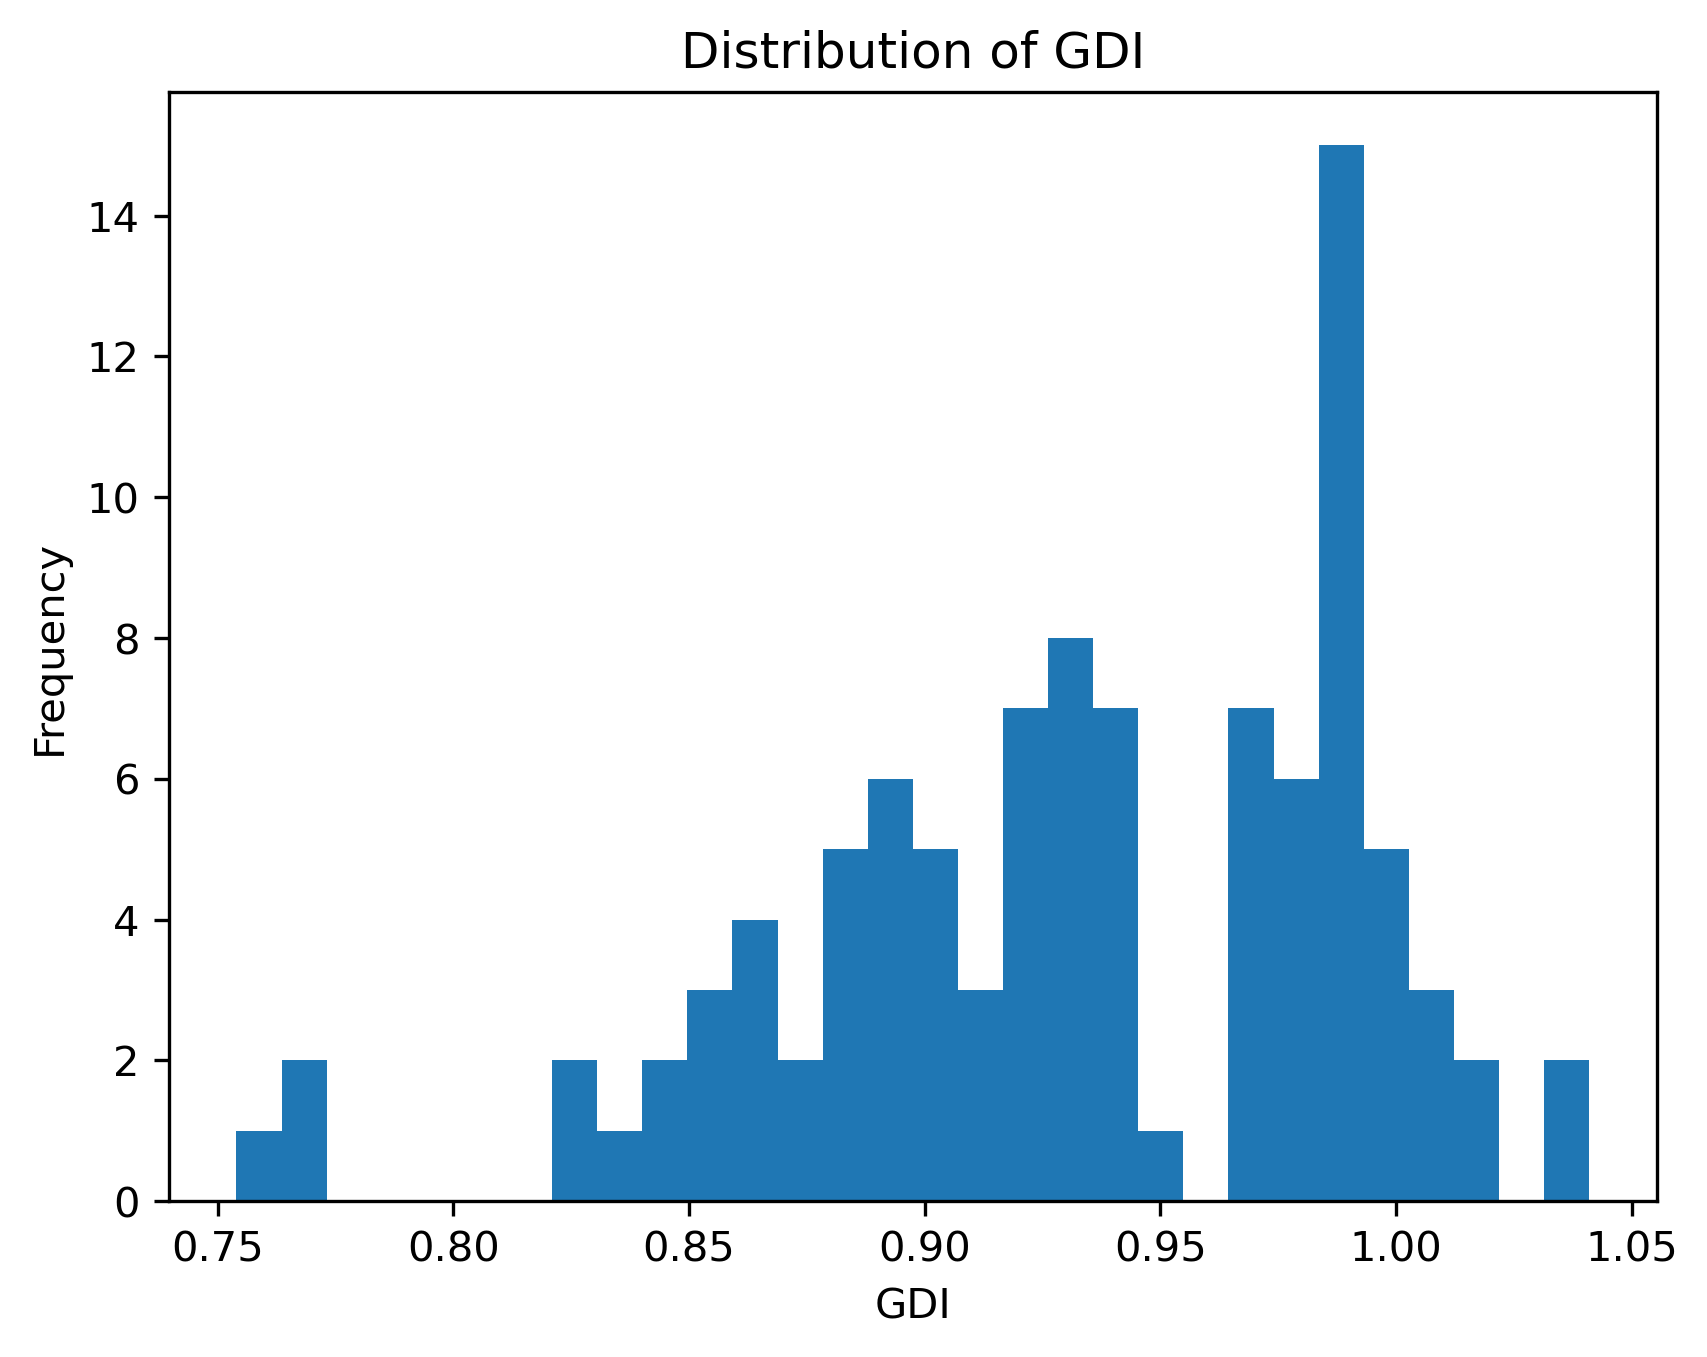

In [13]:
data['gdi'].hist(bins=30)
plt.title('Distribution of GDI')
plt.xlabel('GDI')
plt.ylabel('Frequency')
plt.grid(False)
plt.show()

# 02 check the predicted values with small number of women level penetrations 

In [14]:
for indicator in ['internet','mobile']:
    data_path = params.dropbox_data_path / f"combined_data/updated_ground_truth_and_fb/{indicator}"
    data = pd.read_csv(data_path / f"combined_multiple_years_no_missing_keep_countries_fb_aligned.csv")
    data = deleting_itu_func(data, f'{indicator}_ggi', indicator,True)

In [15]:
# read predictions first 
folder = (params.EXTERNAL / 'pipeline/result')
files = folder.glob('national/*.csv')
df_predictions = pd.concat([pd.read_csv(f) for f in files])
df_predictions.drop(columns=['Unnamed: 0'],inplace=True)
df_predictions.rename(columns={'gid_0': 'iso3'}, inplace=True)

# extract year from date
df_predictions['year'] = df_predictions['date'].astype(str).str[:4].astype(int)
df_predictions_yearly = df_predictions.groupby(['iso3','year','outcome']).mean(numeric_only=True).reset_index()

# read the data file 
CIS_countries = params.CIS_countries

for indicator in ['internet']:
    data_path = params.dropbox_data_path / f"combined_data/updated_ground_truth_and_fb/{indicator}"
    data = pd.read_csv(data_path / f"combined_multiple_years_no_missing_keep_countries_fb_aligned.csv")
    data = deleting_itu_func(data, f'{indicator}_ggi', indicator,True)

# read the data  contains all the fb values and the offline features
df_data = pd.read_csv(str(params.FB_PREPROCESSED) + "/fb_national_sd_rolling_std_202606.csv")  #this file contains all the fb values and the offline features
df_data_yearly = df_data.groupby(['iso3','year']).mean(numeric_only=True).reset_index()


results_df=pd.read_csv(params.dropbox_data_path.parent/f'results/logs/ols{"_no_ITU" if deleting_itu else ""}{"_with_year" if with_year else ""}_results_summary.csv')
results_df_CIS=results_df.loc[results_df['model_type'].str.contains('combined_with_CIS')]

NameError: name 'with_year' is not defined

In [16]:
threshold = 0.05
deleting_itu = True
with_year = True

In [17]:
selected_df = df_data_yearly.loc[df_data_yearly['fb_18_999_wom']<threshold,]
selected_df.drop(columns=['month'], inplace=True)
countries = selected_df['iso3'].unique().tolist()
selected_df = selected_df.merge(df_predictions_yearly, on=['iso3','year'], how='left')

## check the pred vs true values 

In [18]:
df_all_res = pd.DataFrame()

for indicator in ['internet', 'mobile']:
    data_path = params.dropbox_data_path / f"combined_data/updated_ground_truth_and_fb/{indicator}"
    data = pd.read_csv(data_path / f"combined_multiple_years_no_missing_keep_countries_fb_aligned.csv")
    data['year'] = data[f'{indicator}_year'] - 2015
    for outcome_var in [f'{indicator}_ggi', f'{indicator}_wom', f'{indicator}_men']:
        
        data[outcome_var] = round(data[outcome_var], 5)
        for model_type in ['combined_with_CIS']:
            
            model_filename = f'{indicator}_{model_type}_{outcome_var}_full_model.pkl'
            model_filepath = params.dropbox_data_path.parent / f'models/OLS' / model_filename
            model = utils.load_model(model_filepath)
            
            predicted_values = model.predict(model.model.exog)
            df_res = pd.DataFrame({
                'year': model.model.data.orig_exog['year'],
                'pred': predicted_values,
                'outcome_var': outcome_var,
                'indicator': indicator,
                'model_type': model_type,
                'true': model.model.endog
            })
            df_res['true'] = df_res['true'].apply(lambda x: round(x, 5))
            df_res = df_res.merge(data[['iso3', outcome_var,'year']], left_on=['true','year'],right_on=[outcome_var,'year'], how='left')
            # for countries with multiple years, take the latest year
            df_res = df_res.sort_values(by=['iso3', 'year']).drop_duplicates(subset=['iso3', 'pred'], keep='last')
            df_all_res = pd.concat([df_all_res, df_res], ignore_index=True)
df_all_res = utils.mark_regions(df_all_res)
df_all_res['pred'] = df_all_res['pred'].clip(0, 1)

    

In [19]:
df_all_res_selected = df_all_res.loc[df_all_res['iso3'].isin(countries)]

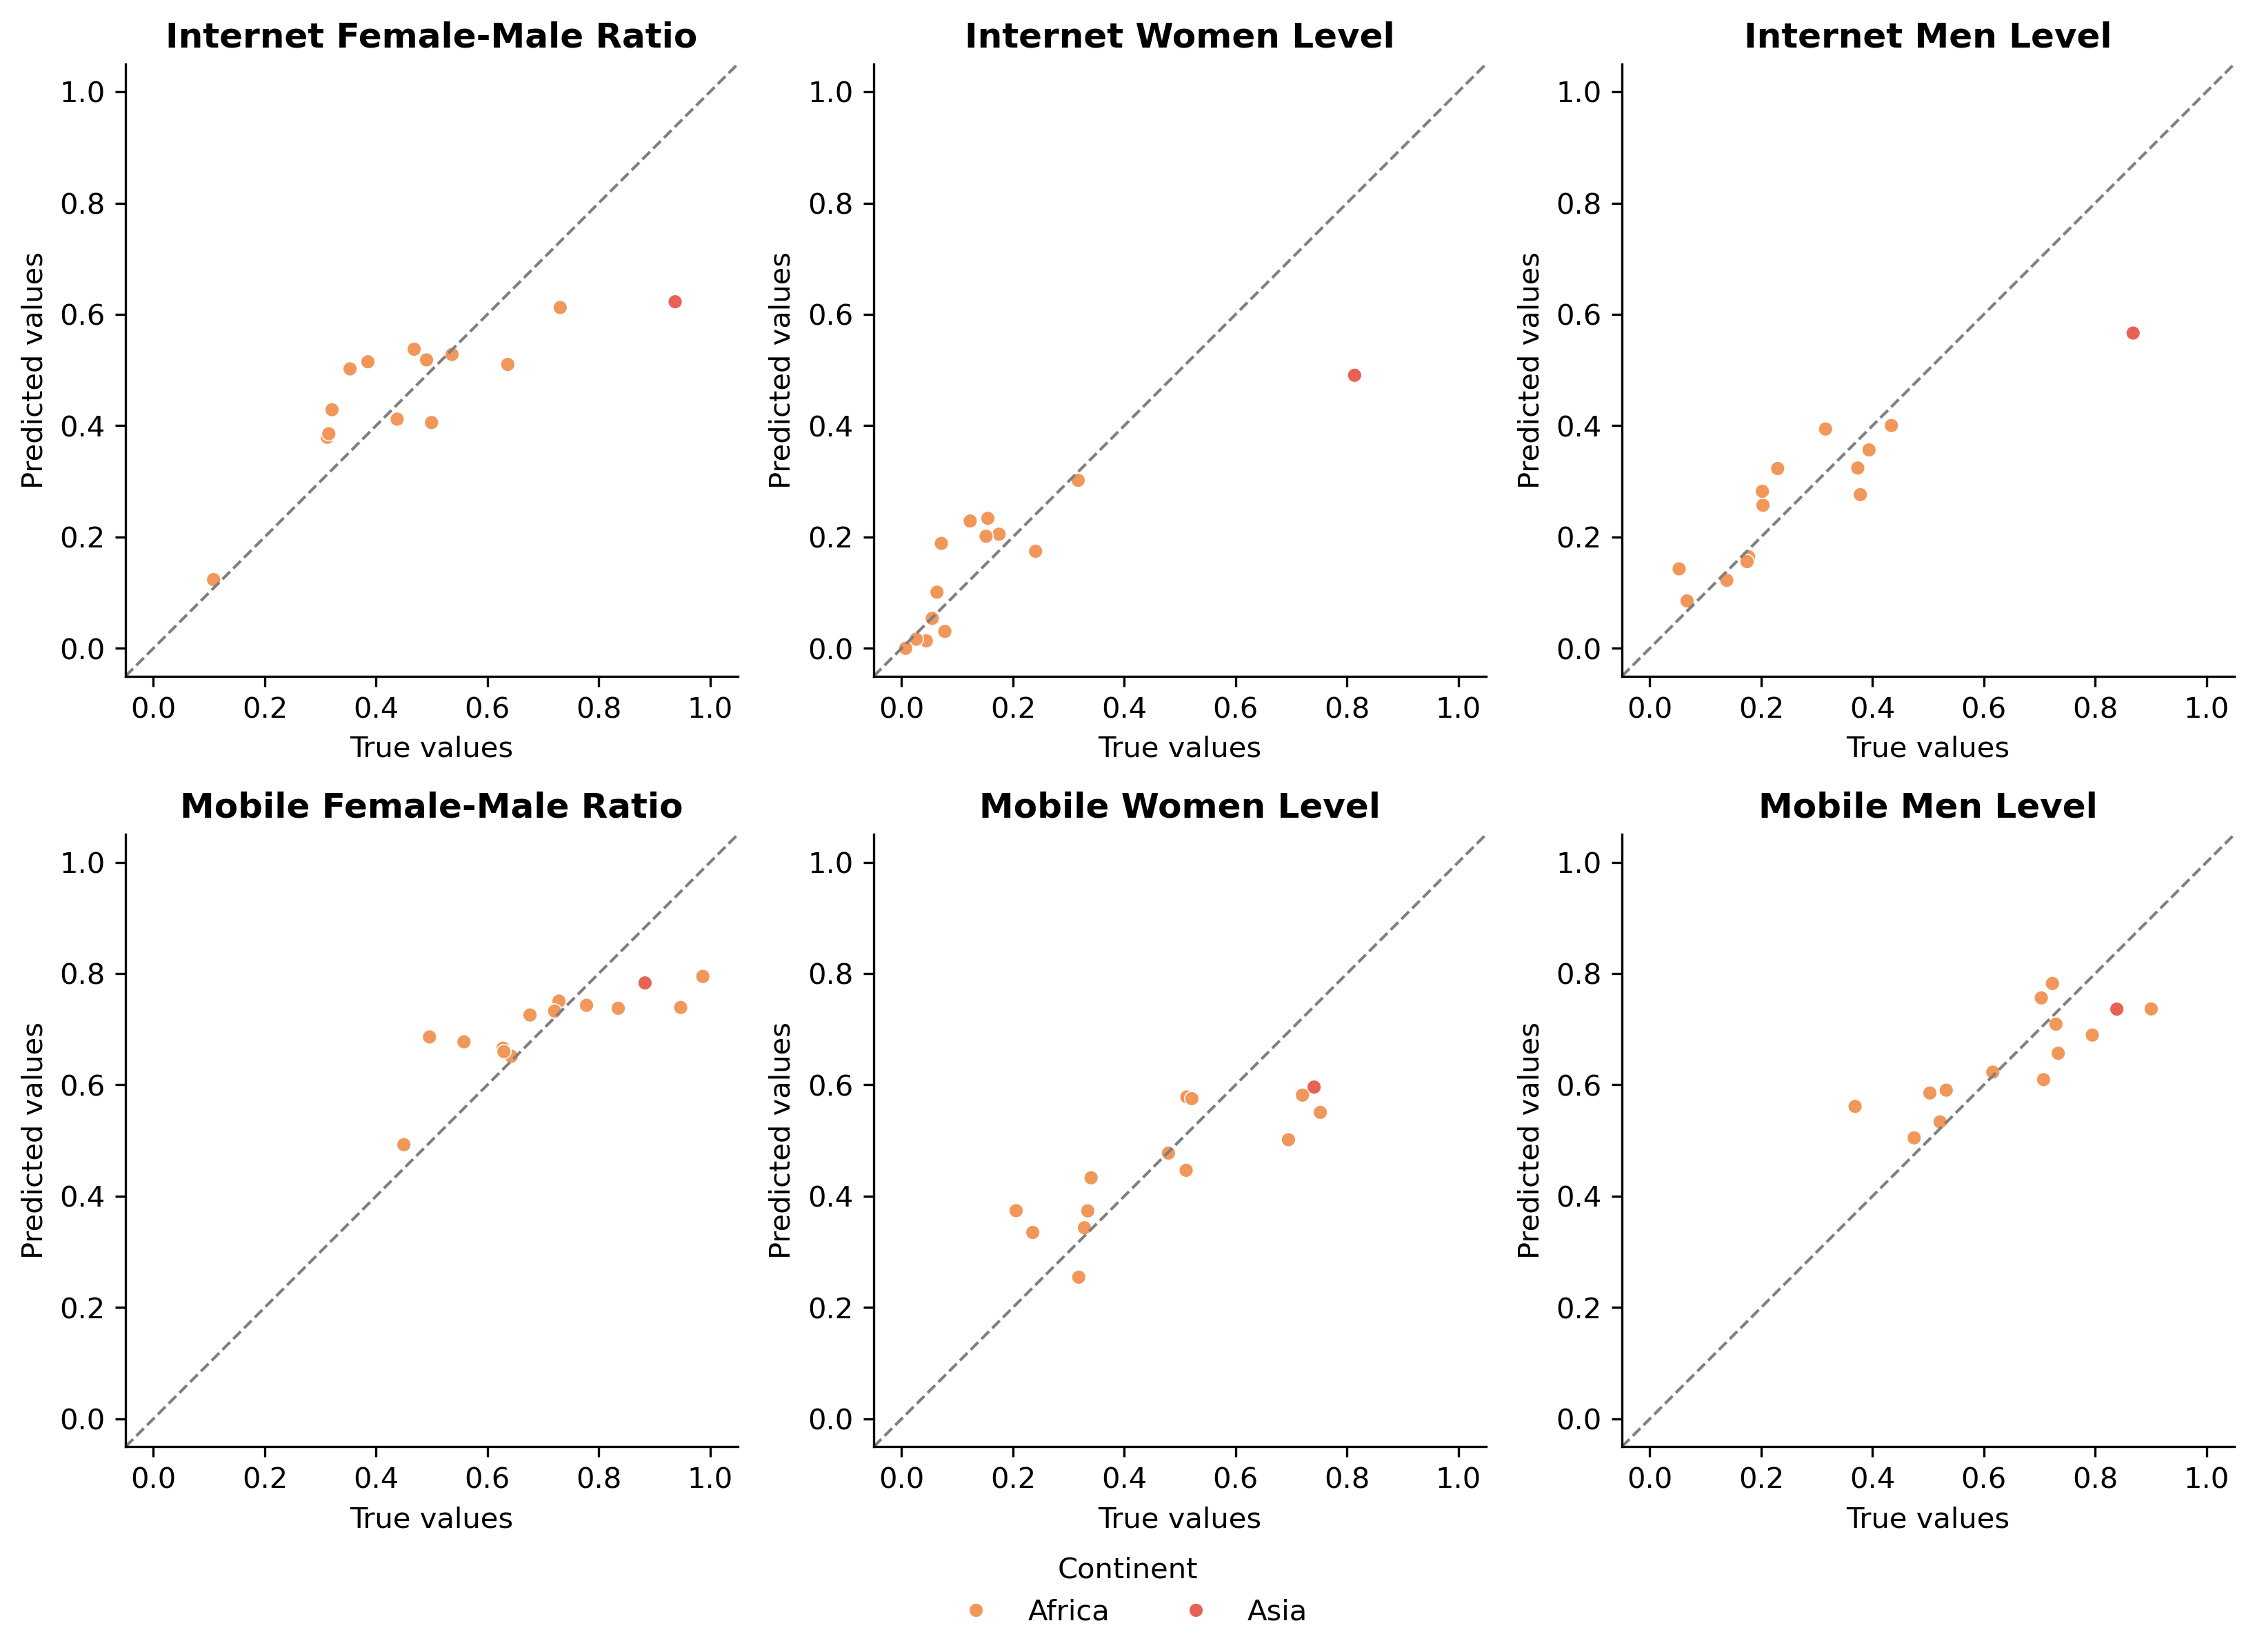

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

hue_column = 'conti'
outcome_name_dict = {"ggi":"Female-Male Ratio","men":"Men Level","wom":"Women Level"}

# ---------------- Prep ----------------

region_colors = {
    "Asia":"#e76254",  # Coral red
    "North America":"#7db782",  # Yellow-orange
    "Africa":"#f1975a",  # Light beige
    "South America":"#72c0c5",  # Pale cyan
    "Oceania":"#cf8dc5",  # Light blue
    "Europe":"#5f799a",  # Medium blue
    "Global":"#101c2c"   # Dark blue
}

# Split "outcome_var" -> indicator + outcome_core (e.g., "internet_ggi")
parts = df_all_res_selected['outcome_var'].str.extract(r'^(internet|mobile)_(ggi|wom|men)$')
df_plot = df_all_res_selected.copy()
df_plot['indicator'] = parts[0]
df_plot['outcome_core'] = parts[1]
df_plot = df_plot.dropna(subset=['indicator', 'outcome_core'])

# ---------------- Subplot Setup ----------------
fig, axes = plt.subplots(2, 3, figsize=(11, 8))
outcome_cores = ['ggi', 'wom', 'men']
indicators = ['internet', 'mobile']

for i, indicator in enumerate(indicators):
    for j, outcome in enumerate(outcome_cores):
        ax = axes[i, j]
        data = df_plot[(df_plot['indicator'] == indicator) & (df_plot['outcome_core'] == outcome)]

        sns.scatterplot(
            data=data,
            x='true',
            y='pred',
            hue=hue_column,
            palette=region_colors,
            s=25,
            alpha=1,
            ax=ax,
            legend=False if i + j > 0 else True  # show legend only once
        )

        ax.plot([-0.05, 1.05], [-0.05, 1.05], color='grey', linestyle='--', linewidth=1)
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)
        ax.set_aspect('equal', adjustable='box')


        ax.set_xlabel("True values")
        ax.set_ylabel("Predicted values")


        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        ax.set_title(f"{indicator.capitalize()} {outcome_name_dict.get(outcome, outcome)}", fontweight='bold')

# remove legend from first subplot
axes[0, 0].legend_.remove()

# Adjust layout and legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title='Continent', loc='lower center', ncol=6, frameon=False)
plt.tight_layout(rect=[0, 0.05, 1, 1])

# save or show
# plt.savefig(params.FIG / "pred_vs_true_2x3_grid.png", bbox_inches='tight')
plt.show()

In [21]:
df_plot

,year,pred,outcome_var,indicator,model_type,true,iso3,internet_ggi,internet_wom,internet_men,mobile_ggi,mobile_wom,mobile_men,conti,subregion,region,outcome_core
0,0.0,0.537402,internet_ggi,internet,combined_with_CIS,0.46848,AGO,0.46848,NaN,NaN,NaN,NaN,NaN,Africa,Africa,Sub-Saharan Africa,ggi
6,1.0,0.428619,internet_ggi,internet,combined_with_CIS,0.32087,BDI,0.32087,NaN,NaN,NaN,NaN,NaN,Africa,Africa,Sub-Saharan Africa,ggi
8,2.0,0.379151,internet_ggi,internet,combined_with_CIS,0.31248,BEN,0.31248,NaN,NaN,NaN,NaN,NaN,Africa,Africa,Sub-Saharan Africa,ggi
9,6.0,0.518257,internet_ggi,internet,combined_with_CIS,0.49065,BEN,0.49065,NaN,NaN,NaN,NaN,NaN,Africa,Africa,Sub-Saharan Africa,ggi
10,6.0,0.514785,internet_ggi,internet,combined_with_CIS,0.38536,BFA,0.38536,NaN,NaN,NaN,NaN,NaN,Africa,Africa,Sub-Saharan Africa,ggi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
601,4.0,0.622885,mobile_men,mobile,combined_with_CIS,0.61611,RWA,NaN,NaN,NaN,NaN,NaN,0.61611,Africa,Africa,Sub-Saharan Africa,men
613,4.0,0.609459,mobile_men,mobile,combined_with_CIS,0.70735,TCD,NaN,NaN,NaN,NaN,NaN,0.70735,Africa,Africa,Sub-Saharan Africa,men
623,7.0,0.736107,mobile_men,mobile,combined_with_CIS,0.83900,UZB,NaN,NaN,NaN,NaN,NaN,0.83900,Asia,Asia,Europe & Central Asia,men
628,0.0,0.656825,mobile_men,mobile,combined_with_CIS,0.73365,ZWE,NaN,NaN,NaN,NaN,NaN,0.73365,Africa,Africa,Sub-Saharan Africa,men


## compare with trends 

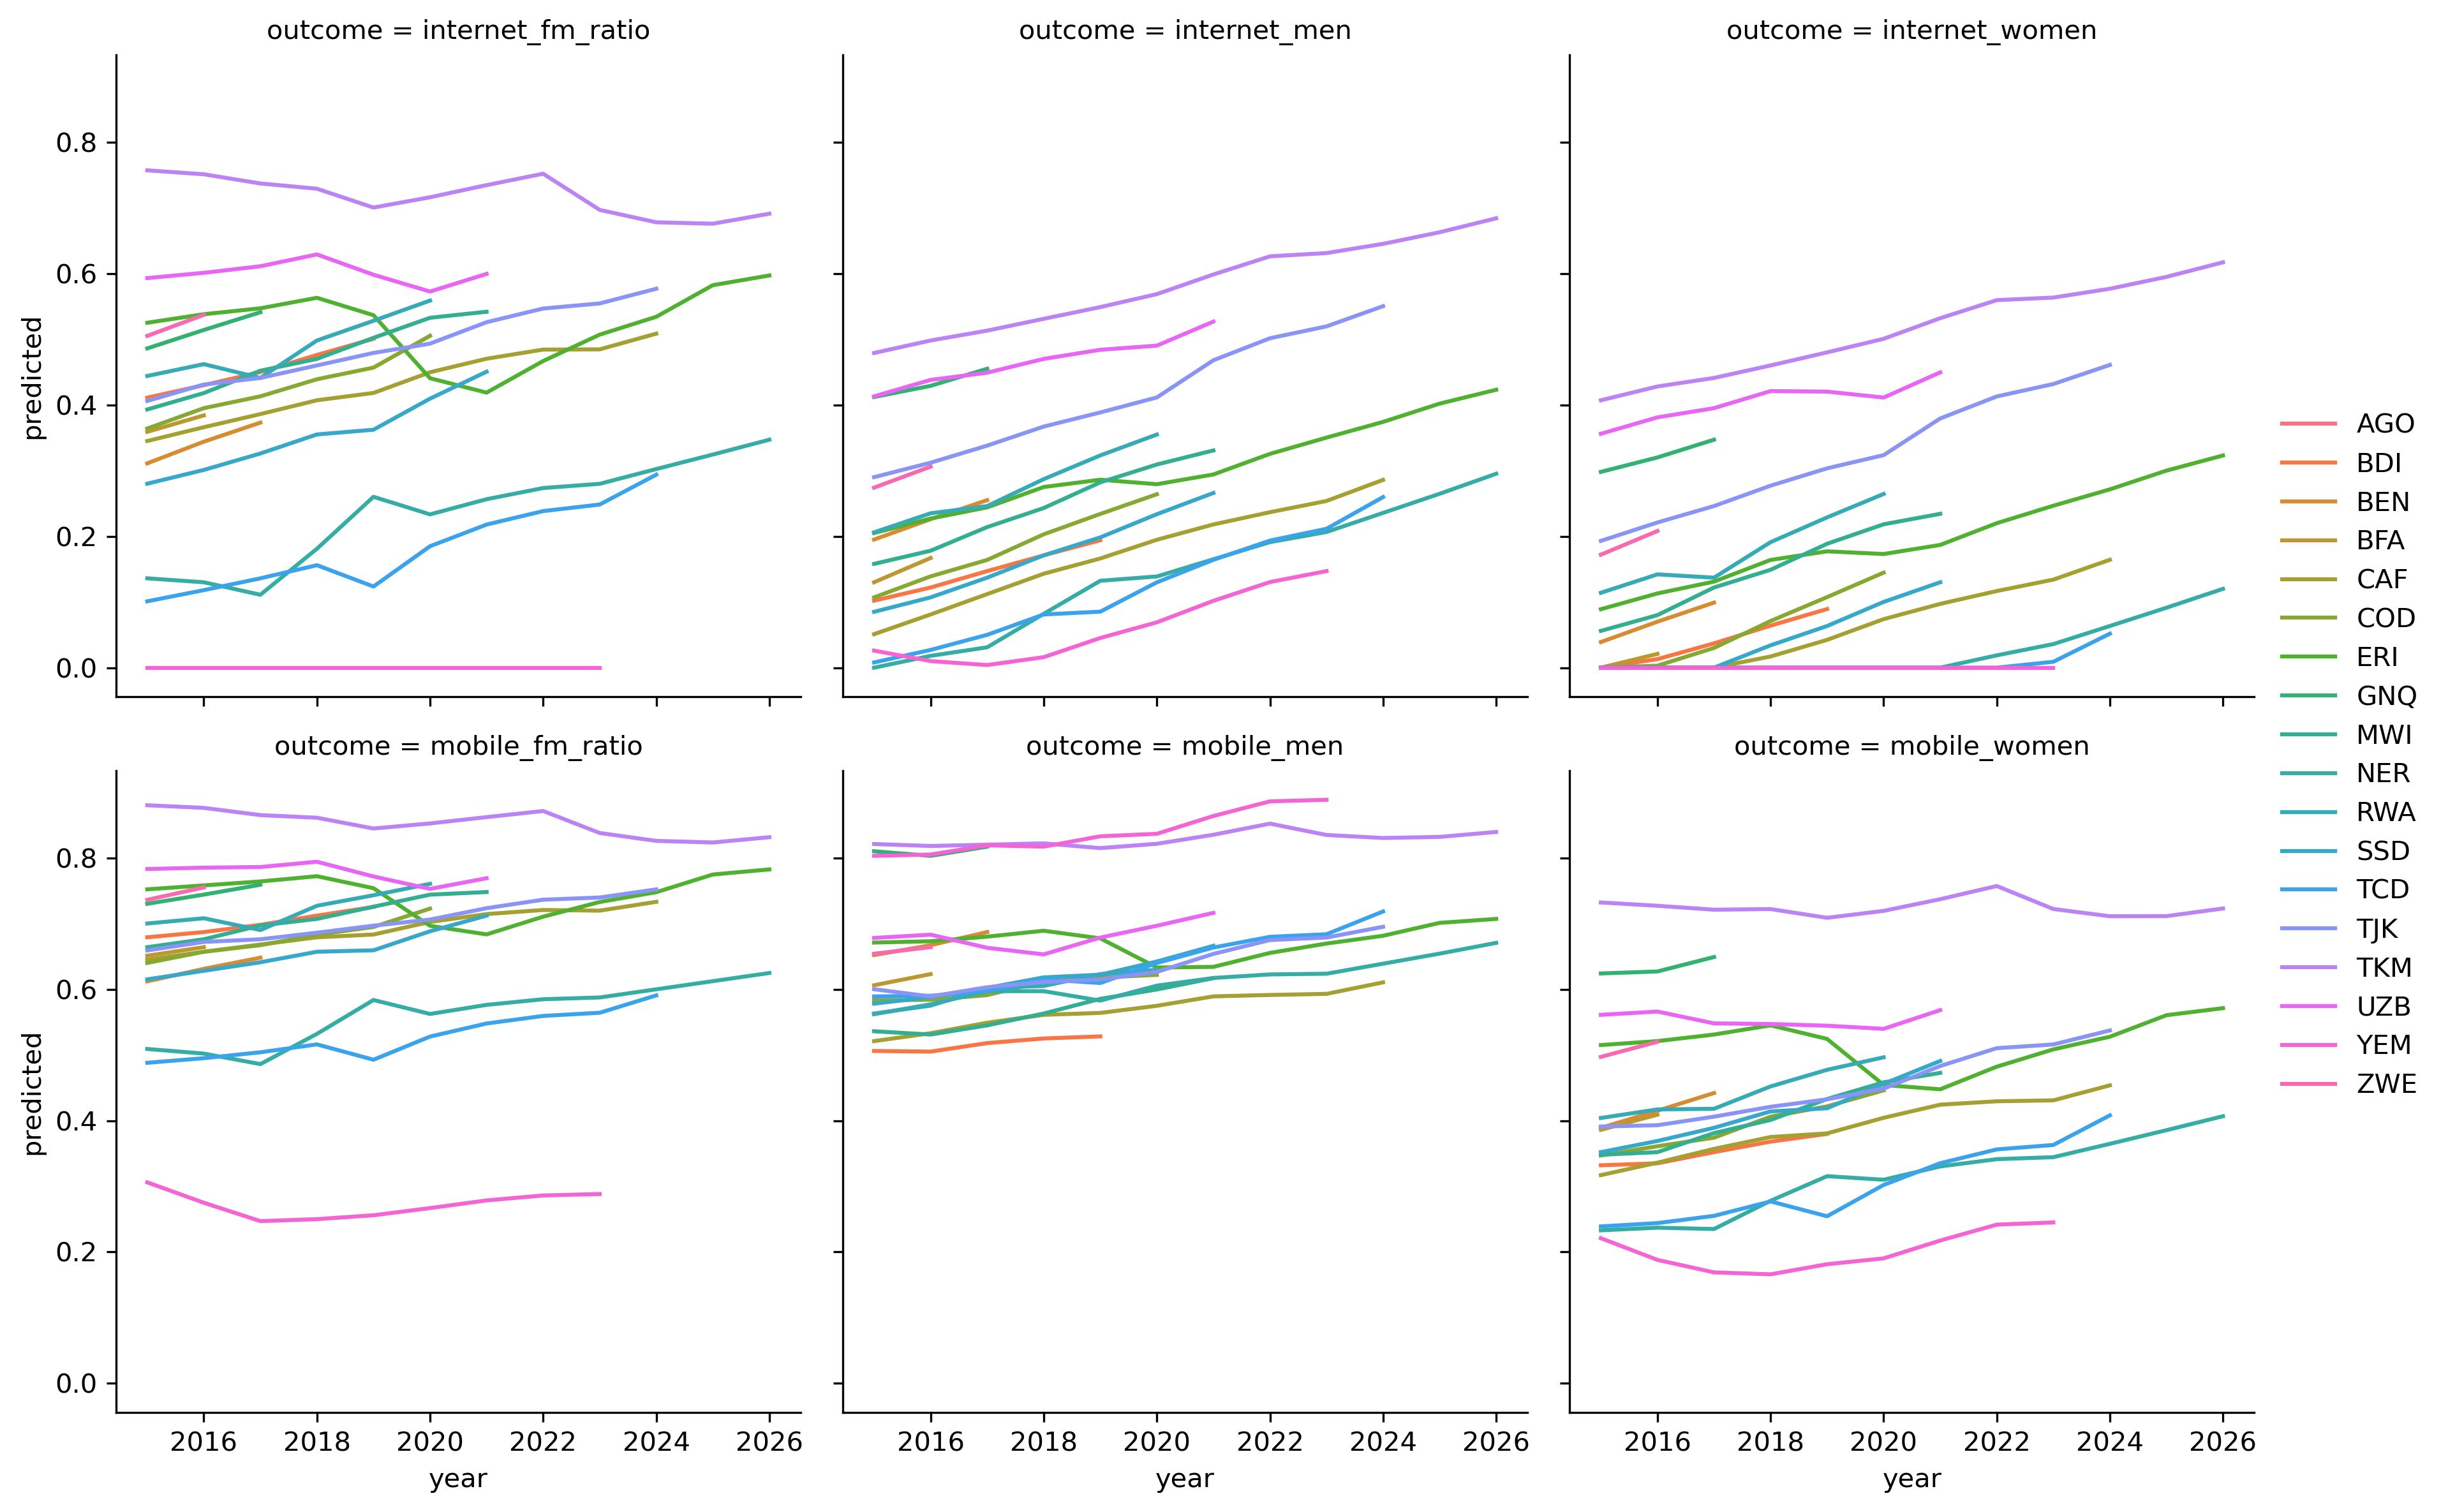

In [22]:
# facet by outcome, i want to show the trends of selected_df's predicted value over time column 'year'

import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(selected_df, col="outcome", col_wrap=3, height=4)
g.map_dataframe(sns.lineplot, x="year", y="predicted", hue='iso3')
g.add_legend()


In [23]:
selected_df_avg = selected_df.pivot_table(index=['iso3', 'year'], columns='outcome', values=['predicted_error', 'predicted']).reset_index()
selected_df_avg.columns = [''.join(col).strip().replace('predicted','') if col[1] else col[0] for col in selected_df_avg.columns.values]

In [24]:
selected_df_avg

,iso3,year,internet_fm_ratio,internet_men,internet_women,mobile_fm_ratio,mobile_men,mobile_women,_errorinternet_fm_ratio,_errorinternet_men,_errorinternet_women,_errormobile_fm_ratio,_errormobile_men,_errormobile_women
0,AGO,2015,0.540,0.323000,0.205,0.752000,0.756000,0.579000,0.074,0.078,0.080,0.058,0.069,0.077
1,BDI,2015,0.411,0.102000,0.000,0.679000,0.506000,0.332000,0.078,0.082,0.085,0.062,0.073,0.081
2,BDI,2016,0.430,0.122000,0.013,0.687000,0.505000,0.335000,0.078,0.082,0.085,0.062,0.073,0.081
3,BDI,2017,0.450,0.147000,0.037,0.698000,0.518000,0.352000,0.078,0.082,0.085,0.062,0.073,0.081
4,BDI,2018,0.476,0.171000,0.064,0.712000,0.525000,0.368000,0.078,0.082,0.085,0.062,0.073,0.081
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,YEM,2021,0.000,0.101750,0.000,0.278500,0.863667,0.217417,0.039,0.041,0.042,0.030,0.036,0.040
120,YEM,2022,0.000,0.130333,0.000,0.286083,0.885917,0.241667,0.039,0.041,0.042,0.030,0.036,0.040
121,YEM,2023,0.000,0.147000,0.000,0.288250,0.888333,0.245000,0.039,0.041,0.042,0.030,0.036,0.040
122,ZWE,2015,0.505,0.274000,0.172,0.736000,0.654000,0.497000,0.078,0.082,0.085,0.062,0.073,0.081


In [25]:
# concat the groundtruth data 
selected_df = pd.merge(selected_df,data[['iso3',f'{indicator}_ggi',f'{indicator}_men',f'{indicator}_wom']],on='iso3',how='left')

In [26]:
selected_df_avg = selected_df.groupby(['iso3', 'outcome']).mean().reset_index()

In [27]:
selected_df_avg

,iso3,outcome,year,fb_18_999_r,fb_18_999_wom,fb_18_999_men,predicted,predicted_error,mobile_ggi,mobile_men,mobile_wom
0,AGO,internet_fm_ratio,2015.0,0.690731,0.045467,0.065825,0.5400,0.0740,NaN,0.70322,NaN
1,AGO,internet_men,2015.0,0.690731,0.045467,0.065825,0.3230,0.0780,NaN,0.70322,NaN
2,AGO,internet_women,2015.0,0.690731,0.045467,0.065825,0.2050,0.0800,NaN,0.70322,NaN
3,AGO,mobile_fm_ratio,2015.0,0.690731,0.045467,0.065825,0.7520,0.0580,NaN,0.70322,NaN
4,AGO,mobile_men,2015.0,0.690731,0.045467,0.065825,0.7560,0.0690,NaN,0.70322,NaN
...,...,...,...,...,...,...,...,...,...,...,...
103,ZWE,internet_men,2015.5,0.497945,0.045227,0.090716,0.2900,0.0825,NaN,0.73161,NaN
104,ZWE,internet_women,2015.5,0.497945,0.045227,0.090716,0.1900,0.0850,NaN,0.73161,NaN
105,ZWE,mobile_fm_ratio,2015.5,0.497945,0.045227,0.090716,0.7455,0.0620,NaN,0.73161,NaN
106,ZWE,mobile_men,2015.5,0.497945,0.045227,0.090716,0.6590,0.0735,NaN,0.73161,NaN


# 03 change model specification and see the coefficients 

In [28]:
# Initialize empty DataFrames to store results
country_specific_df = pd.DataFrame(columns=["name", 'outcome_var', 'model_type', 'country', 'pred', 'true', 'train_size'])
year_specific_df = pd.DataFrame(columns=["name", 'outcome_var', 'model_type', 'year', 'pred', 'true', 'train_size'])

# Define a list of CIS countries
CIS_countries = params.CIS_countries


def deleting_itu_func(data,outcome_var,indicator,CIS_control=False):
    """
    Function to filter and preprocess data by removing ITU-related entries.
    
    Args:
        data (pd.DataFrame): Input dataset.
        outcome_var (str): Target variable for the model.
        indicator (str): Indicator variable (e.g., 'internet', 'mobile').
        CIS_control (bool): Whether to apply specific rules for CIS countries.

    Returns:
        pd.DataFrame: Processed dataset with ITU-related entries removed.

    """
    data = data.loc[~data['iso3'].isin(params.sanction_countries)]
    if CIS_control:
        for iso3 in data.iso3.unique():
            if iso3 in CIS_countries:
                if ('itu' in data.loc[data['iso3']==iso3,f'{indicator}_survey_type'].values) & (data.loc[data['iso3']==iso3,f'{indicator}_survey_type'].nunique()==1):
                        continue
                        #print('CIS',iso3),
                        #print(iso3,data.loc[data['iso3']==iso3,f'{outcome_var}'].values),
                        #survey_values = [x if x>0.8 else None for x in data.loc[data['iso3']==iso3,f'{outcome_var}'].values],
                        #data.loc[data['iso3']==iso3,f'{outcome_var}']= survey_values,
                        #print(data.loc[data['iso3']==iso3,f'{outcome_var}'].values),
                    
                else:
                    data.loc[data['iso3']==iso3,f'{outcome_var}']=[x if y!='itu' else None for x,y in zip(data.loc[data['iso3']==iso3,f'{outcome_var}'],data.loc[data['iso3']==iso3,f'{indicator}_survey_type'])]
            
            elif data.loc[data['iso3']==iso3,'conti'].values[0] in ['Europe','North America','South America']:
                if ('itu' in data.loc[data['iso3']==iso3,f'{indicator}_survey_type'].values) & (data.loc[data['iso3']==iso3,f'{indicator}_survey_type'].nunique()==1):
                    
                    #survey_values = [x if y>0.85 else None for x,y in zip(data.loc[data['iso3']==iso3,f'{outcome_var}'],data.loc[data['iso3']==iso3,f'internet_wom'])]
                    survey_values = [x if y>0.85 else None for x,y in zip(data.loc[data['iso3']==iso3,f'{outcome_var}'],data.loc[data['iso3']==iso3,f'{indicator}_wom'])]
                    data.loc[data['iso3']==iso3,f'{outcome_var}']=  survey_values
                    #print(data.loc[data['iso3']==iso3,f'{outcome_var}'].values),
                else:
                    data.loc[data['iso3']==iso3,f'{outcome_var}']=[x if y!='itu' else None for x,y in zip(data.loc[data['iso3']==iso3,f'{outcome_var}'],data.loc[data['iso3']==iso3,f'{indicator}_survey_type'])]
            else:
                data.loc[data['iso3']==iso3,f'{outcome_var}']=[x if y!='itu' else None for x,y in zip(data.loc[data['iso3']==iso3,f'{outcome_var}'],data.loc[data['iso3']==iso3,f'{indicator}_survey_type'])]

    else:
        data = data.loc[data[f'{indicator}_survey_type']!='itu']
    return data



def save_scaler(scaler, file_path):
    joblib.dump(scaler, file_path)

def save_model(model, file_path):
    joblib.dump(model, file_path)


def load_model(file_path):
    return joblib.load(file_path) if os.path.exists(file_path) else None


# Function to preprocess data
def preprocess_data(data):
    non_numeric_cols = data.select_dtypes(exclude=['number']).columns
    if len(non_numeric_cols) > 0:
        data = pd.get_dummies(data, columns=non_numeric_cols)
    return data

def align_model_spec(model_spec,model_type,outcome_var):
    if 'align' in model_type: 
        model_spec = [x for x in model_spec if 'fb' not in x]
    if 'offline' not in model_type:
        model_spec.append('fb_18_999_r' if 'ggi' in outcome_var else 'fb_18_999_wom' if 'wom' in outcome_var else 'fb_18_999_men')
    return model_spec
        
        
# Main function with model selection
def evaluate_model(indicator, outcome_var, dataset, model_type, model_spec, regression_method, alpha=0.5, country_specific_df=country_specific_df, year_specific_df=year_specific_df,spec_align_ctrl=False):
    """
    Evaluate a regression model using the specified method (OLS or Lasso).

    Args:
        indicator (str): Indicator variable (e.g., 'internet', 'mobile').
        outcome_var (str): Target variable for the model.
        dataset (pd.DataFrame): Input dataset.
        model_type (str): Type of model (e.g., 'combined', 'online').
        model_spec (list): List of feature columns for the model.
        regression_method (str): Regression method ('OLS' or 'Lasso').
        alpha (float): Regularization parameter for Lasso regression.
        country_specific_df (pd.DataFrame): DataFrame to store country-specific results.
        year_specific_df (pd.DataFrame): DataFrame to store year-specific results.

    Returns:
        tuple: Updated year-specific and country-specific DataFrames, and results DataFrame.
    """
    
    model_spec = align_model_spec(model_spec,model_type,outcome_var)
    
    data = dataset.copy()
    
    # Drop rows where the target variable is missing
    if deleting_itu:
        data = deleting_itu_func(data, outcome_var, indicator, True if 'CIS' in model_type else False)
        print(f'{outcome_var}: {data[outcome_var].notnull().sum()} samples left for modelling')
    data = data.dropna(subset=[outcome_var])
    
    # Preprocess the data
    X = preprocess_data(data[model_spec])
    y = data[outcome_var].astype(float)
    
    # Define file paths for saving the model
    model_filename = f'{indicator}_{model_type}_{outcome_var}_full_model.pkl' if deleting_itu else f'{indicator}_{model_type}_{outcome_var.replace(f"{indicator}_", "")}_{outcome_var}_full_model.pkl'
    model_filepath = params.dropbox_data_path.parent / f'models/OLS' / model_filename
    
    # Train the model based on the specified regression method
    if regression_method == 'OLS':
        X_const = sm.add_constant(X)  # Add constant term for intercept
        model = sm.OLS(y, X_const).fit()
        y_pred_full = model.predict(X_const)
        r2_full_sample = model.rsquared
        r2_adj = model.rsquared_adj
    elif regression_method == 'Lasso':
        model = Lasso(alpha=alpha)
        model.fit(X, y)
        y_pred_full = model.predict(X)
        r2_full_sample = r2_score(y, y_pred_full)
        r2_adj = 1 - (1 - r2_full_sample) * (len(y) - 1) / (len(y) - X.shape[1] - 1)
    else:
        raise ValueError("Unsupported regression method. Choose 'OLS' or 'Lasso'.")
    
    # Save the trained model
    save_model(model, model_filepath)


    # Variable importance/selection (only for Lasso)
    selected_vars = []
    if regression_method == 'Lasso':
        selected_vars = [var for var, coef in zip(X.columns, model.coef_) if coef != 0]
    else:
        selected_vars = model_spec

    # Leave-one-out evaluation

    def leave_one_column_out(column):
        """
        Perform leave-one-out evaluation for a specific column.

        Args:
            column (str): Column to leave out.

        Returns:
            tuple: DataFrame with predictions and R² score.
        """
        recorder = pd.DataFrame(columns=["name", 'outcome_var', 'model_type', column, 'pred', 'true', 'train_size'])
        for unique_value in data[column].unique():

            if regression_method == 'OLS':
                X_train_loo = X_const[data[column] != unique_value]
                y_train_loo = y[data[column] != unique_value]
                X_test_loo = X_const[data[column] == unique_value]
                y_test_loo = y[data[column] == unique_value]

                model = sm.OLS(y_train_loo, X_train_loo).fit()
                y_pred_loo = model.predict(X_test_loo).values


            else:
                X_train_loo = X[data[column] != unique_value]
                y_train_loo = y[data[column] != unique_value]
                X_test_loo = X[data[column] == unique_value]
                y_test_loo = y[data[column] == unique_value]

                model.fit(X_train_loo, y_train_loo)
                y_pred_loo = model.predict(X_test_loo)

            for i in range(len(y_pred_loo)):

                recorder.loc[len(recorder)] = [f'{indicator} {model_type}', outcome_var, model_type, unique_value, y_pred_loo[i], y_test_loo.values[i], len(y_train_loo)]

        r2 = r2_score(recorder['true'], recorder['pred'])

        return recorder, r2
    
    # Perform leave-one-out evaluations for 'iso3' and 'year'
    r2s = {}
    for leave_column in ['iso3', 'year']:
        temp, r2s[leave_column] = leave_one_column_out(leave_column)
        if leave_column == 'iso3':
            country_specific_df = pd.concat([country_specific_df, temp], axis=0)
        elif leave_column == 'year':
            year_specific_df = pd.concat([year_specific_df, temp], axis=0)

    # Append results
    results_df.loc[len(results_df)] = {
        "model_name": f'{indicator} {model_type}',
        'method': regression_method,
        'outcome_var': outcome_var,
        "model_type": model_type,
        'best_r2': r2_full_sample,
        'adj_r2': r2_adj,
        'loco_r2': r2s['iso3'],
        'loyo_r2': r2s['year'],
        'selected_var': ', '.join(selected_vars)
    }

    return year_specific_df, country_specific_df, results_df


In [29]:
deleting_itu = True 
with_year = True
regression_method = 'OLS'

# define zones
fb_cols =["fb_18_999_men","fb_18_999_wom","fb_18_999_r"]
#bg_cols = params.bg_cols
bg_cols = ['hdi','gdi','gdp_pcap','year']
model_specs = {'online_with_CIS_align': fb_cols, 
                'offline_with_CIS_align': bg_cols, 
                #'combined': fb_cols + bg_cols,
                #'combined_top_shaps':['gggi_ggi','se_r','hdi','gdp_pcap','wdi_fertility','year']+fb_cols,
                #'combined_top_shaps_no_fertility':['gggi_ggi','se_r','hdi','gdp_pcap','year']+fb_cols,
                "combined_with_CIS_align":fb_cols + bg_cols}
                #"combined_top_shaps_from_mobile":['wdi_litrad','gni_pc','hdi','year','ineq_le','wdi_acel','gii']+fb_cols}

# Define a list of CIS countries
CIS_countries = ['BEL', 'KAZ', 'ARM', "KGZ", 'MDA', "AZE", 'TKJ', 'UZB', 'TKM']



In [30]:
# Initialize an empty DataFrame to store the results
results_df = pd.DataFrame(columns=['model_name', 'method', 'outcome_var', 'model_type', 'best_r2','adj_r2', 'loco_r2', 'loyo_r2', 'selected_var'])
country_specific_df = pd.DataFrame(columns=["name", 'outcome_var', 'model_type', 'country', 'pred', 'true', 'train_size'])
year_specific_df = pd.DataFrame(columns=["name", 'outcome_var', 'model_type', 'year', 'pred', 'true', 'train_size'])

from pathlib import Path
df_outcomes = pd.read_csv(Path(params.RAW / "new_groundtruth_national_data.csv"))
df_outcomes = df_outcomes.loc[df_outcomes['survey_year']>=2015]

df_outcomes=df_outcomes.pivot_table(index=['gid_0','source','survey_year'],columns="outcome",values='observed').reset_index()



for indicator in ['internet','mobile']:
    
    data_path = params.dropbox_data_path / f"combined_data/updated_ground_truth_and_fb/{indicator}"
    data = pd.read_csv(data_path / f"combined_multiple_years_no_missing_keep_countries_fb_aligned.csv")
    data['year']=data[f'{indicator}_year']-2015
    # deleting ITU 
    if indicator=='mobile':
        data = data.merge(df_outcomes[['gid_0','source','survey_year','internet_women']],left_on=['iso3',f'{indicator}_year',f'{indicator}_survey_type'],right_on=['gid_0','survey_year','source'],how='left')
        data.rename(columns={'internet_women':'internet_wom'},inplace=True)
       

    for model_type in model_specs.keys():
        for outcome_var in [f'{indicator}_ggi', f'{indicator}_wom', f'{indicator}_men']:
            #print(outcome_var, model_specs[model_type])
            year_specific_df, country_specific_df, results_df = evaluate_model(indicator,outcome_var, data, model_type,model_specs[model_type], regression_method, 0.1, country_specific_df, year_specific_df)
    


internet_ggi: 108 samples left for modelling
internet_wom: 108 samples left for modelling


internet_men: 108 samples left for modelling
internet_ggi: 108 samples left for modelling


internet_wom: 108 samples left for modelling
internet_men: 108 samples left for modelling


internet_ggi: 108 samples left for modelling
internet_wom: 108 samples left for modelling


internet_men: 108 samples left for modelling
mobile_ggi: 99 samples left for modelling


mobile_wom: 99 samples left for modelling
mobile_men: 99 samples left for modelling


mobile_ggi: 99 samples left for modelling
mobile_wom: 99 samples left for modelling


mobile_men: 99 samples left for modelling
mobile_ggi: 99 samples left for modelling


mobile_wom: 99 samples left for modelling
mobile_men: 99 samples left for modelling


In [31]:
results_df

,model_name,method,outcome_var,model_type,best_r2,adj_r2,loco_r2,loyo_r2,selected_var
0,internet online_with_CIS_align,OLS,internet_ggi,online_with_CIS_align,0.664824,0.661662,0.649183,0.649179,fb_18_999_r
1,internet online_with_CIS_align,OLS,internet_wom,online_with_CIS_align,0.676737,0.673687,0.663109,0.618333,fb_18_999_wom
2,internet online_with_CIS_align,OLS,internet_men,online_with_CIS_align,0.547489,0.543220,0.526009,0.433905,fb_18_999_men
3,internet offline_with_CIS_align,OLS,internet_ggi,offline_with_CIS_align,0.746179,0.736322,0.718681,0.626923,"hdi, gdi, gdp_pcap, year"
4,internet offline_with_CIS_align,OLS,internet_wom,offline_with_CIS_align,0.874909,0.870052,0.858665,0.818882,"hdi, gdi, gdp_pcap, year"
5,internet offline_with_CIS_align,OLS,internet_men,offline_with_CIS_align,0.813636,0.806399,0.788899,0.742065,"hdi, gdi, gdp_pcap, year"
6,internet combined_with_CIS_align,OLS,internet_ggi,combined_with_CIS_align,0.765153,0.753641,0.731091,0.653138,"hdi, gdi, gdp_pcap, year, fb_18_999_r"
7,internet combined_with_CIS_align,OLS,internet_wom,combined_with_CIS_align,0.891607,0.886294,0.873767,0.862372,"hdi, gdi, gdp_pcap, year, fb_18_999_wom"
8,internet combined_with_CIS_align,OLS,internet_men,combined_with_CIS_align,0.859306,0.852409,0.836149,0.824402,"hdi, gdi, gdp_pcap, year, fb_18_999_men"
9,mobile online_with_CIS_align,OLS,mobile_ggi,online_with_CIS_align,0.575574,0.571199,0.552618,0.555879,fb_18_999_r


In [32]:
# save the results
country_specific_df.to_csv(params.dropbox_data_path.parent/f'results/logs/ols{"_no_ITU" if deleting_itu else ""}{"_with_year" if with_year else ""}_loco_results_align.csv', index=False)
year_specific_df.to_csv(params.dropbox_data_path.parent/f'results/logs/ols{"_no_ITU" if deleting_itu else ""}{"_with_year" if with_year else ""}_loyo_results_align.csv', index=False)
results_df.to_csv(params.dropbox_data_path.parent/f'results/logs/ols{"_no_ITU" if deleting_itu else ""}{"_with_year" if with_year else ""}_results_summary_align.csv', index=False)

In [33]:
results_df=pd.read_csv(params.dropbox_data_path.parent/f'results/logs/ols{"_no_ITU" if deleting_itu else ""}{"_with_year" if with_year else ""}_results_summary_align.csv')
results_df_CIS=results_df.loc[results_df['model_type'].str.contains('CIS')]

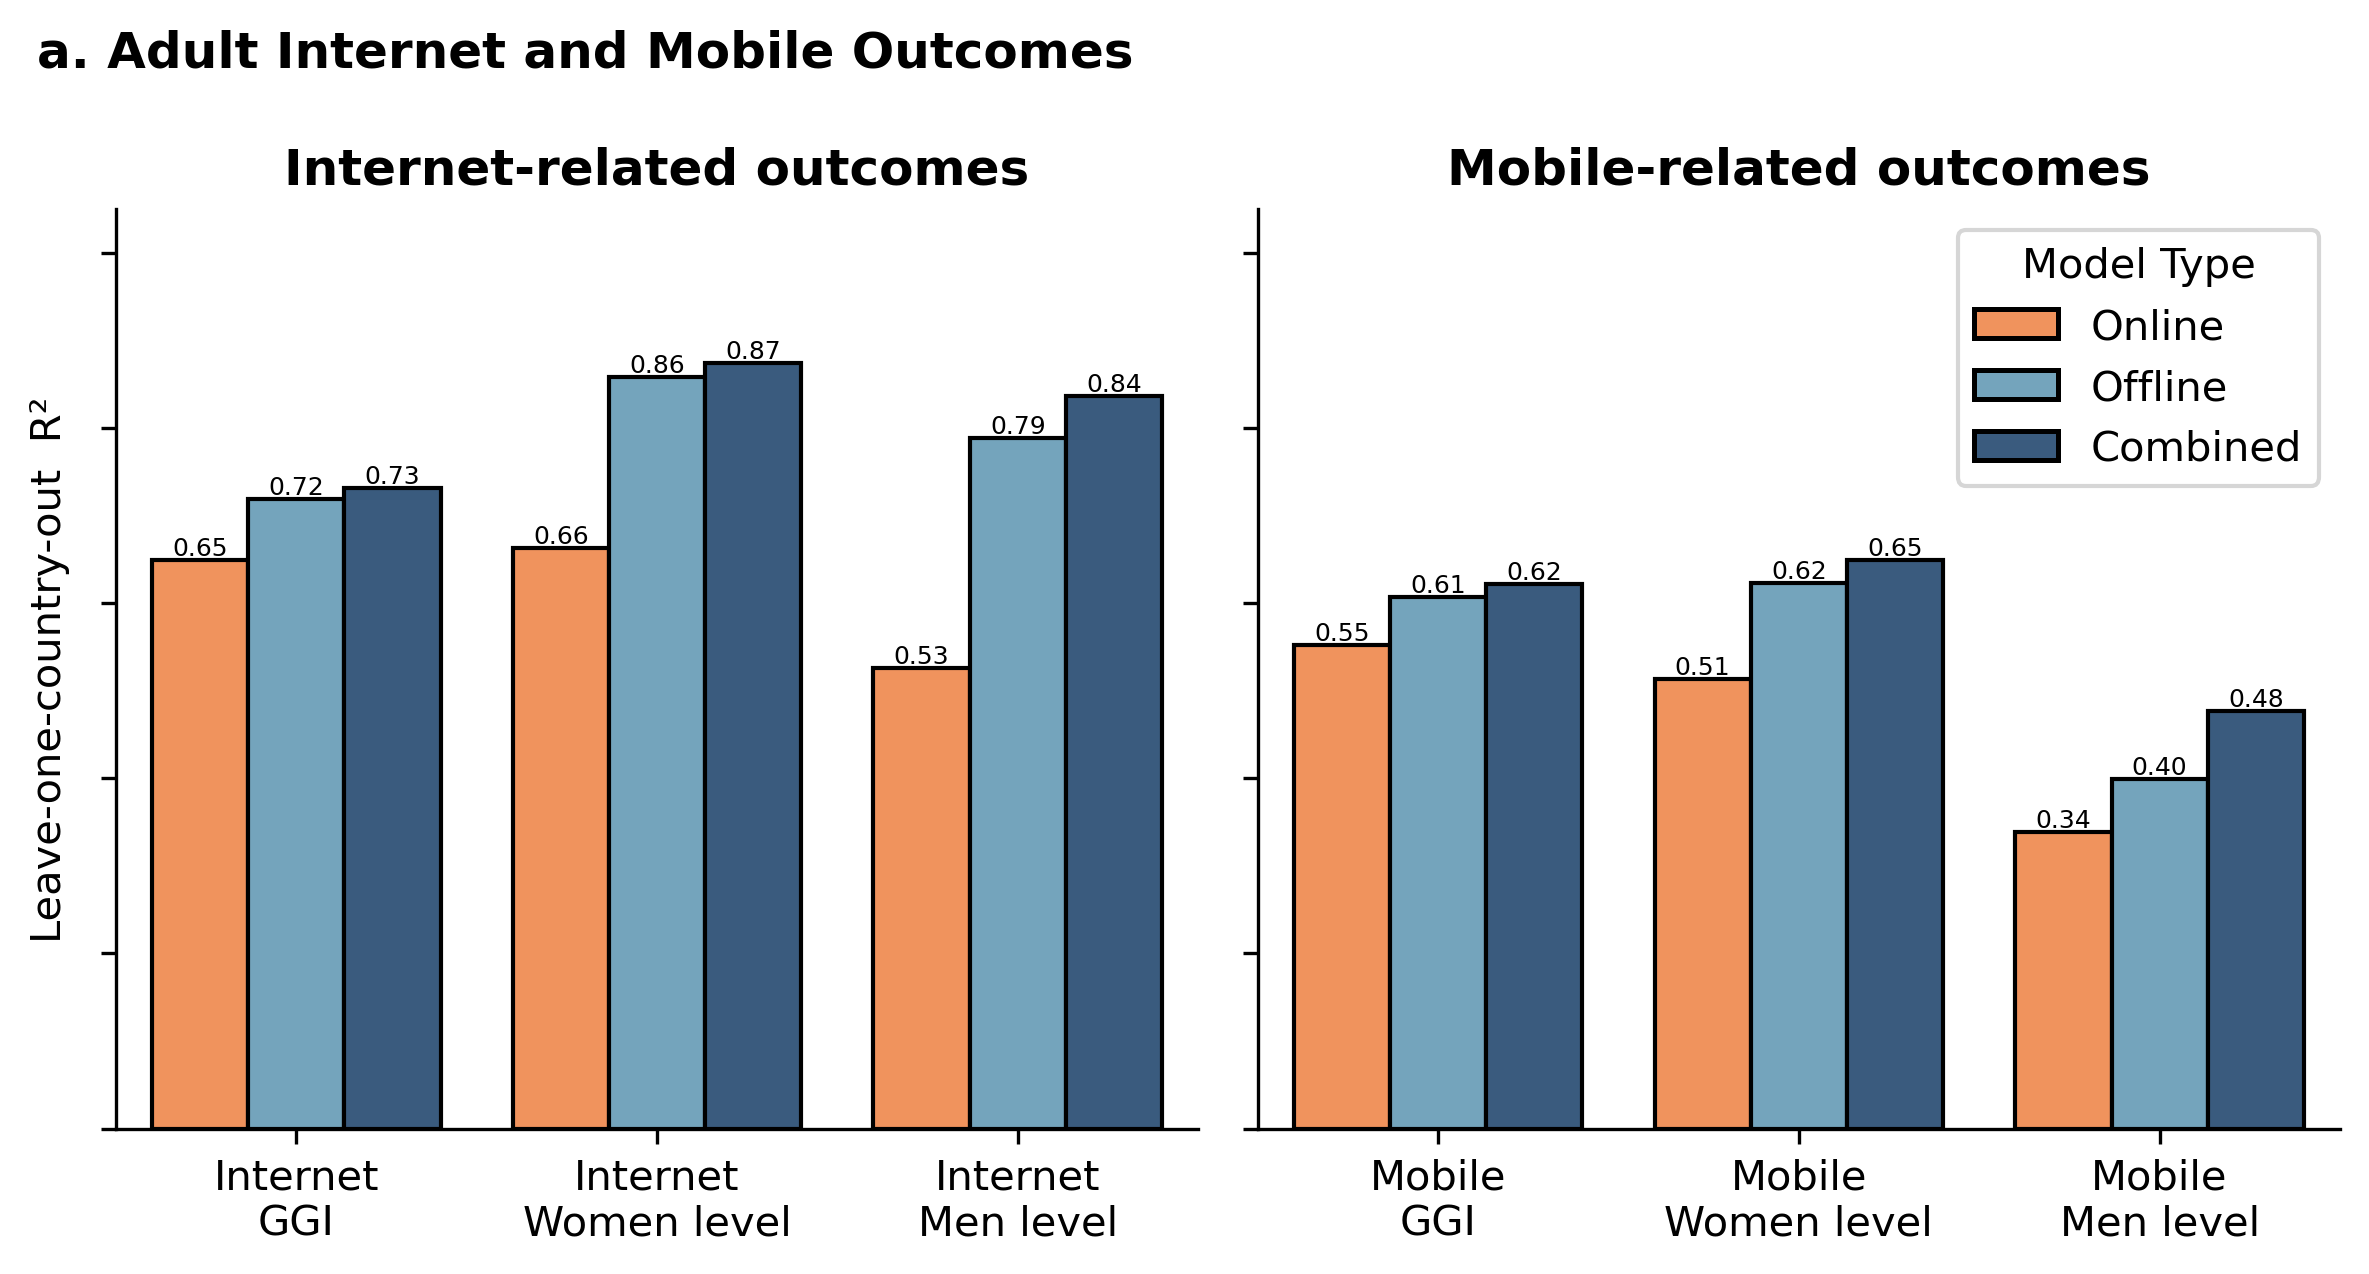

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from pathlib import Path

# --- Prep ---
df = results_df_CIS.copy()
df['model_type'] = df['model_type'].str.replace('_with_CIS_align', '', regex=False)

# Format labels for x-axis
df["formatted_label"] = (
    df["outcome_var"]
    .str.capitalize()
    .str.replace("_", "\n", regex=False)
    .str.replace("men", "Men level", regex=False)
    .str.replace("wom", "Women level", regex=False)
    .str.replace("ggi", "GGI", regex=False)
)

# Split into internet and mobile outcome sets
df_internet = df[df["outcome_var"].str.contains("internet", case=False)]
df_mobile = df[df["outcome_var"].str.contains("mobile", case=False)]

# Palette for model_type
model_type_palette = {
    "combined": "#3a5b7e",
    "online": "#f0935d",
    "offline": "#74a4bc"
}

# --- Plot ---
fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

for ax, subset, title in zip(
    axs,
    [df_internet, df_mobile],
    ["Internet-related outcomes", "Mobile-related outcomes"]
):
    sns.barplot(
        data=subset,
        x="formatted_label",
        y="loco_r2",
        hue="model_type",
        palette=model_type_palette,
        ax=ax,
        saturation=1
    )

    # Title & labels
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel("Leave-one-country-out  R²" if "Internet" in title else "")
    if "Mobile" in title:
        ax.set_yticklabels([])  # hide y-ticks on right plot
    ax.set_ylim(0, 1.05)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')

    # Black edges on bars
    for patch in ax.patches:
        patch.set_edgecolor('black')
        patch.set_linewidth(1)

    # Add labels on bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', label_type='edge', fontsize=6)

    # Remove clutter
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0)

# --- Legend ---
legend_elements = [
    Patch(facecolor=model_type_palette[m], edgecolor='black', linewidth=1.2, label=m.capitalize())
    for m in ['online', 'offline', 'combined']
]

#axs[0].legend_.remove()
axs[0].legend_.remove()
axs[1].legend(title='Model Type', handles=legend_elements, loc='upper right')

# --- after plotting ---
plt.tight_layout()

# Add a more separated suptitle
fig.suptitle(
    'a. Adult Internet and Mobile Outcomes',
    fontsize=12,
    fontweight='bold',
    y=1.05,x=0.25# push it higher above the subplot titles
)

# Add extra top margin so suptitle doesn't overlap with subplots
plt.subplots_adjust(top=0.9)

# plt.savefig(params.FIG / 'ols_loco_r2_by_outcome_var_grouped.pdf', bbox_inches='tight')


## get the betas from the models 

In [35]:
# prepare to check YEM 

for indicator in ['internet']:
    data_path = params.dropbox_data_path / f"combined_data/updated_ground_truth_and_fb/{indicator}"
    data = pd.read_csv(data_path / f"combined_multiple_years_no_missing_keep_countries_fb_aligned.csv")
    data = deleting_itu_func(data, f'{indicator}_ggi', indicator,True)
    

data_yem = data.loc[data['iso3'].isin(['YEM','TCD']),['iso3',"fb_18_999_men","fb_18_999_wom","fb_18_999_r",'hdi','gdi','gdp_pcap']]
data_yem['const'] =1 
data_yem['year']=2025-2015

In [36]:
df_model_params.loc[df_model_params.index[-1],'model']

'mobile_men'

In [37]:

# load model to see the indicators 
df_model_params = pd.DataFrame()
model_specs = {}
model_type = 'combined_with_CIS_align'
deleting_itu = True
for indicator in ['internet','mobile']:
    for outcome_var in [f'{indicator}_ggi', f'{indicator}_wom', f'{indicator}_men']:
        model_filename = f'{indicator}_{model_type}_{outcome_var}_full_model.pkl' if deleting_itu else f'{indicator}_{model_type}_{outcome_var.replace(f"{indicator}_", "")}_{outcome_var}_full_model.pkl'
        model_filepath = params.dropbox_data_path.parent / f'models/OLS' / model_filename
        model = utils.load_model(model_filepath)
        df_model_params = pd.concat([df_model_params, pd.DataFrame(model.params).T], axis=0)
        df_model_params.reset_index(drop=True, inplace=True)
        df_model_params.loc[df_model_params.index[-1],'model'] = outcome_var
        model_specs[outcome_var] = model.params.index.tolist()

# compute YEM prediction
df_model_params['result_yem'] = [data_yem.loc[data_yem['iso3']=='YEM',model_specs[x]].dot(df_model_params.loc[df_model_params['model']==x,model_specs[x]].values[0]).values[0] for x in df_model_params['model']]
df_model_params['result_tcd'] = [data_yem.loc[data_yem['iso3']=='TCD',model_specs[x]].dot(df_model_params.loc[df_model_params['model']==x,model_specs[x]].values[0]).values[0] for x in df_model_params['model']]

# select relevant columns
df_model_params = df_model_params[['result_tcd','result_yem','const', 'fb_18_999_men', 'fb_18_999_wom', 'fb_18_999_r', 'hdi', 'gdi',
       'gdp_pcap', 'year', 'model' ]]
# round values
for col in df_model_params.columns:
    if col != 'model':
        df_model_params[col] = df_model_params[col].round(3)
        

In [38]:
df_model_params

,result_tcd,result_yem,const,fb_18_999_men,fb_18_999_wom,fb_18_999_r,hdi,gdi,gdp_pcap,year,model
0,0.327,-0.067,-0.904,NaN,NaN,0.279,0.677,1.281,-0.028,0.010,internet_ggi
1,0.107,-0.110,-1.182,NaN,0.253,NaN,1.078,0.799,0.006,0.020,internet_wom
2,0.286,0.296,-0.543,0.294,NaN,NaN,0.840,0.243,0.016,0.019,internet_men
3,0.621,0.348,-0.265,NaN,NaN,0.166,0.254,0.870,0.003,0.006,mobile_ggi
4,0.517,0.405,-0.348,NaN,0.195,NaN,0.269,0.387,0.052,0.011,mobile_wom
5,0.778,1.042,0.837,0.196,NaN,NaN,0.109,-0.701,0.055,0.007,mobile_men


## pred vs true

In [39]:
df_all_res = pd.DataFrame()

for indicator in ['internet', 'mobile']:
    data_path = params.dropbox_data_path / f"combined_data/updated_ground_truth_and_fb/{indicator}"
    data = pd.read_csv(data_path / f"combined_multiple_years_no_missing_keep_countries_fb_aligned.csv")
    data['year'] = data[f'{indicator}_year'] - 2015
    for outcome_var in [f'{indicator}_ggi', f'{indicator}_wom', f'{indicator}_men']:
        
        data[outcome_var] = round(data[outcome_var], 5)
        for model_type in ['combined_with_CIS_align']:
            
            model_filename = f'{indicator}_{model_type}_{outcome_var}_full_model.pkl'
            model_filepath = params.dropbox_data_path.parent / f'models/OLS' / model_filename
            model = load_model(model_filepath)
            
            predicted_values = model.predict(model.model.exog)
            df_res = pd.DataFrame({
                'year': model.model.data.orig_exog['year'],
                'pred': predicted_values,
                'outcome_var': outcome_var,
                'indicator': indicator,
                'model_type': model_type,
                'true': model.model.endog
            })
            df_res['true'] = df_res['true'].apply(lambda x: round(x, 5))
            df_res = df_res.merge(data[['iso3', outcome_var,'year']], left_on=['true','year'],right_on=[outcome_var,'year'], how='left')
            # for countries with multiple years, take the latest year
            df_res = df_res.sort_values(by=['iso3', 'year']).drop_duplicates(subset=['iso3', 'pred'], keep='last')
            df_all_res = pd.concat([df_all_res, df_res], ignore_index=True)

df_all_res = utils.mark_regions(df_all_res)
df_all_res['pred'] = df_all_res['pred'].clip(0, 1)


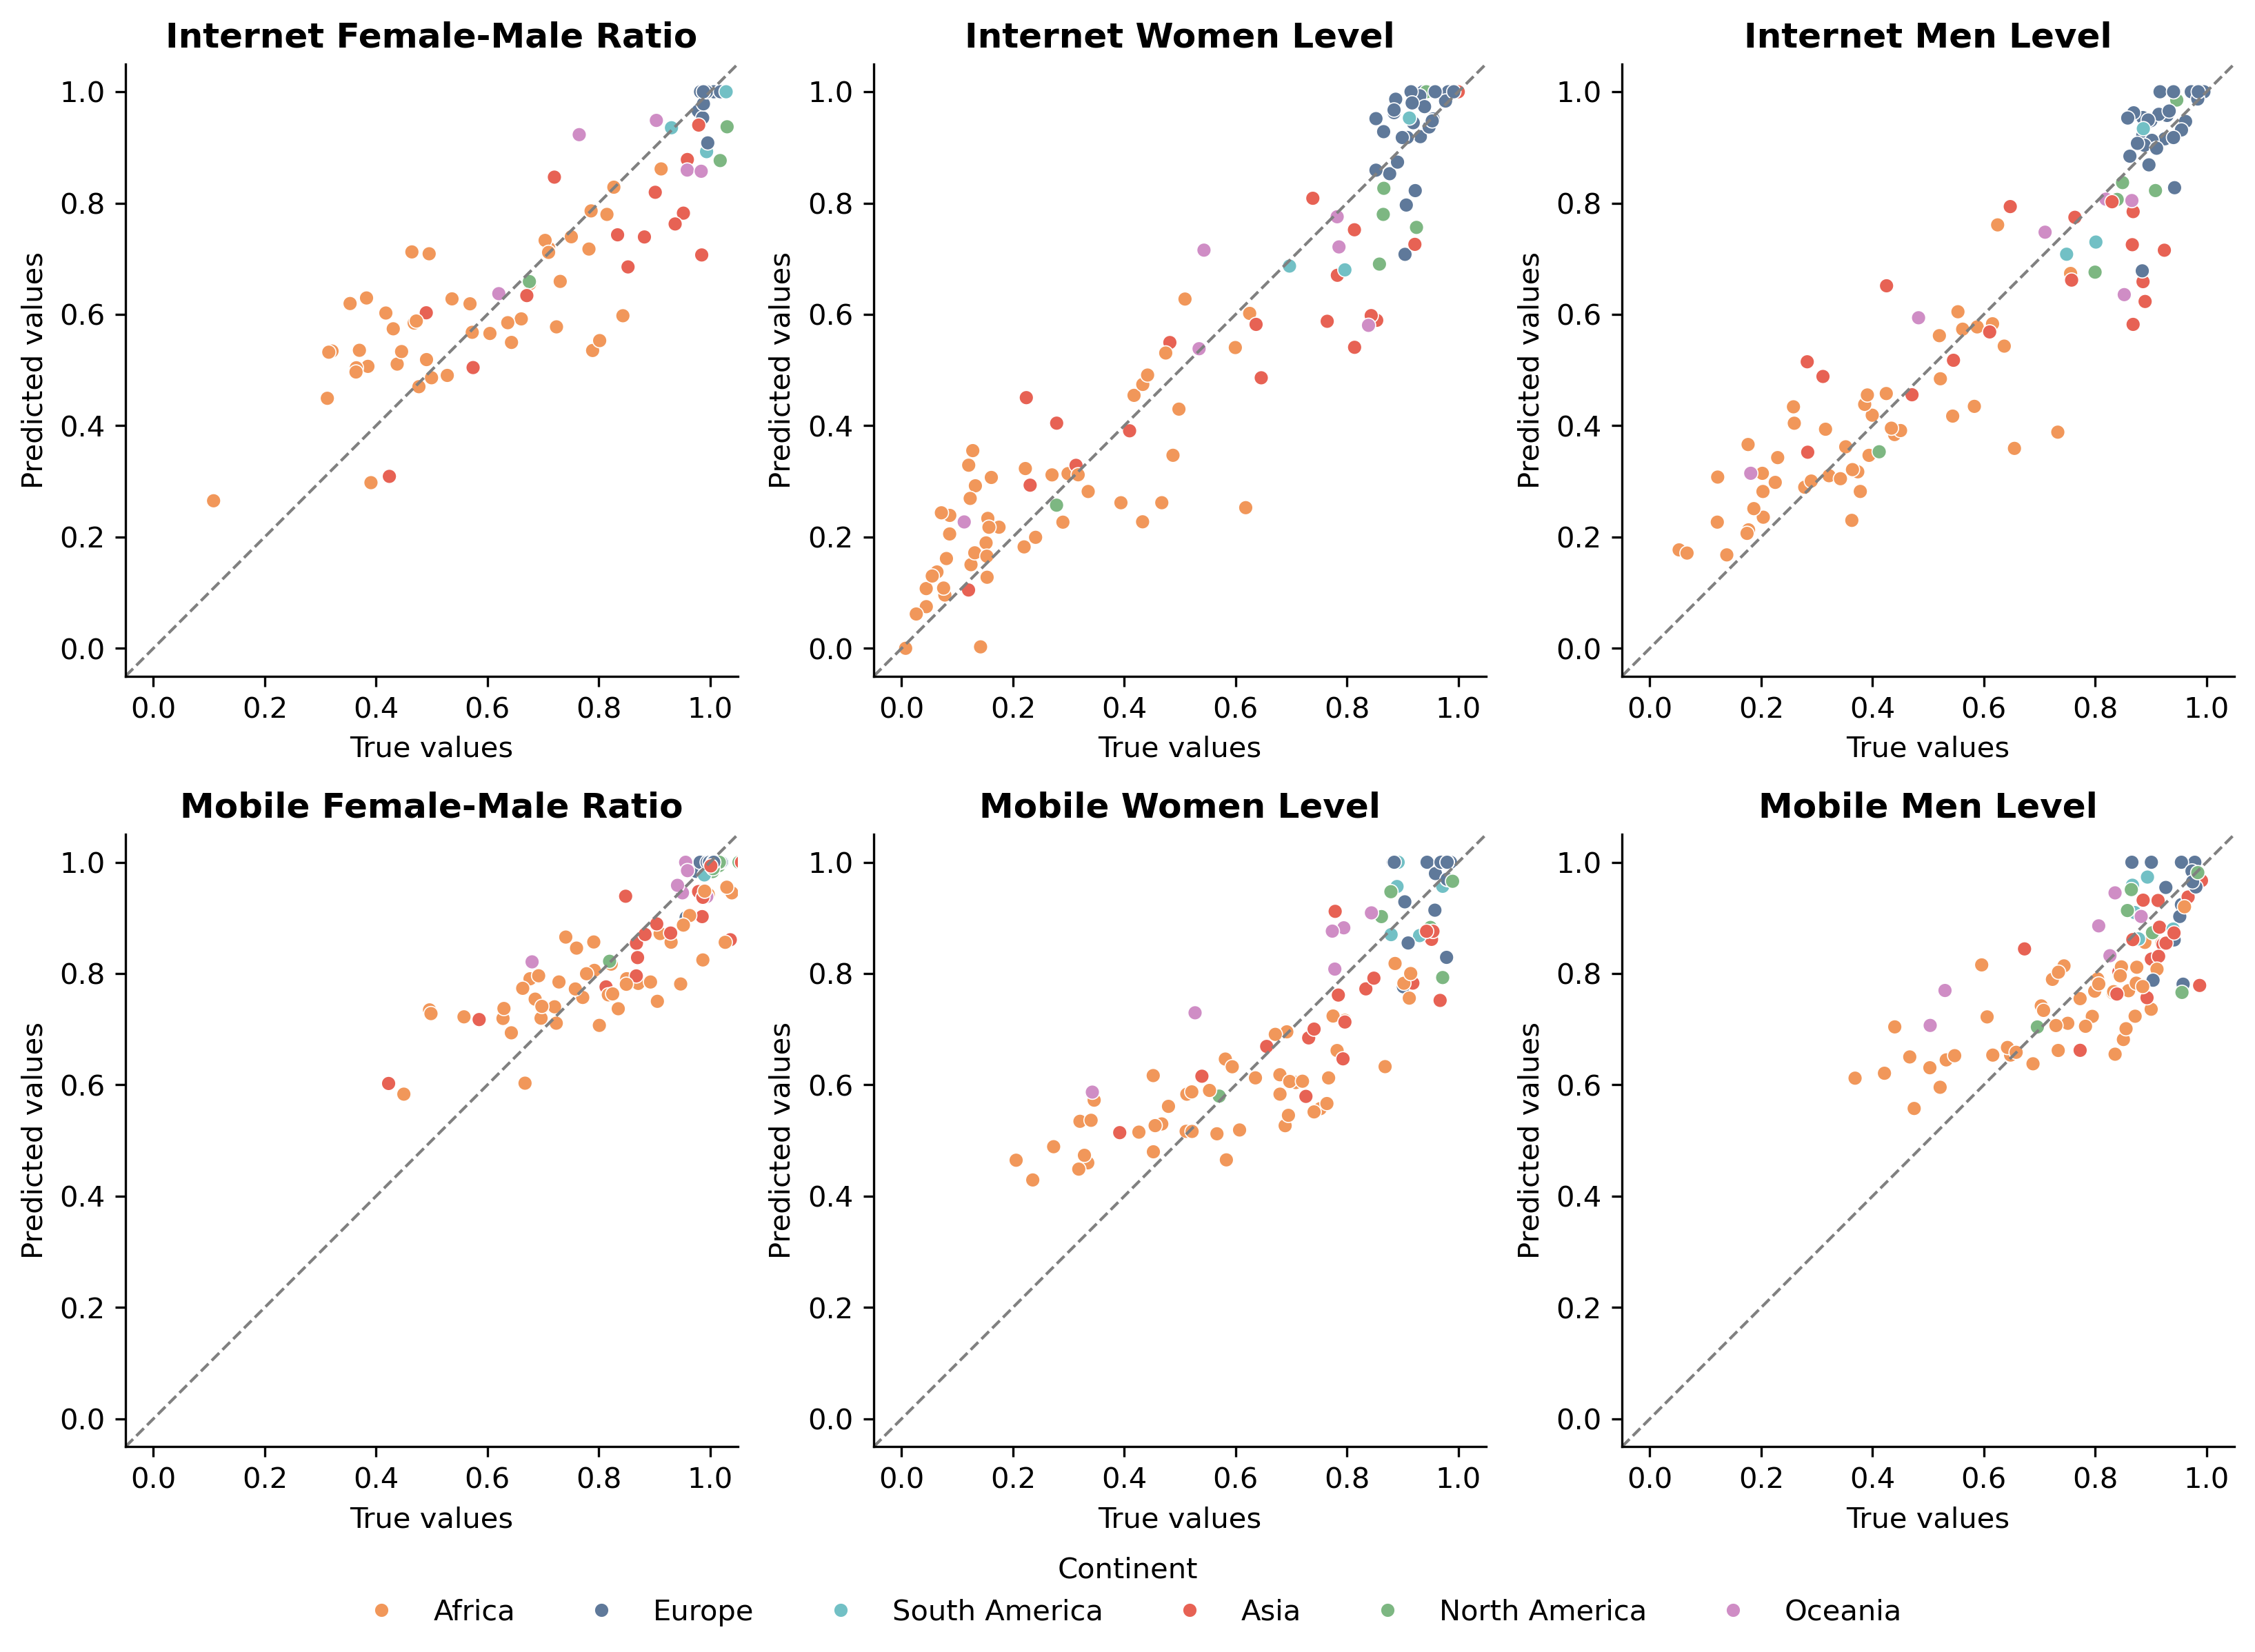

In [40]:
df_all_res = utils.mark_regions(df_all_res)
df_all_res['pred'] = df_all_res['pred'].clip(0, 1)


import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

outcome_name_dict = {"ggi":"Female-Male Ratio","men":"Men Level","wom":"Women Level"}
# ---------------- Prep ----------------

region_colors = {
    "Asia":"#e76254",  # Coral red
    "North America":"#7db782",  # Yellow-orange
    "Africa":"#f1975a",  # Light beige
    "South America":"#72c0c5",  # Pale cyan
    "Oceania":"#cf8dc5",  # Light blue
    "Europe":"#5f799a",  # Medium blue
    "Global":"#101c2c"   # Dark blue
}

# Split "outcome_var" -> indicator + outcome_core (e.g., "internet_ggi")
parts = df_all_res['outcome_var'].str.extract(r'^(internet|mobile)_(ggi|wom|men)$')
df_plot = df_all_res.copy()
df_plot['indicator'] = parts[0]
df_plot['outcome_core'] = parts[1]
df_plot = df_plot.dropna(subset=['indicator', 'outcome_core'])

# ---------------- Subplot Setup ----------------
fig, axes = plt.subplots(2, 3, figsize=(11, 8))
outcome_cores = ['ggi', 'wom', 'men']
indicators = ['internet', 'mobile']

for i, indicator in enumerate(indicators):
    for j, outcome in enumerate(outcome_cores):
        ax = axes[i, j]
        data = df_plot[(df_plot['indicator'] == indicator) & (df_plot['outcome_core'] == outcome)]

        sns.scatterplot(
            data=data,
            x='true',
            y='pred',
            hue=hue_column,
            palette=region_colors,
            s=25,
            alpha=1,
            ax=ax,
            legend=False if i + j > 0 else True  # show legend only once
        )

        ax.plot([-0.05, 1.05], [-0.05, 1.05], color='grey', linestyle='--', linewidth=1)
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)
        ax.set_aspect('equal', adjustable='box')


        ax.set_xlabel("True values")
        ax.set_ylabel("Predicted values")


        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        ax.set_title(f"{indicator.capitalize()} {outcome_name_dict.get(outcome, outcome)}", fontweight='bold')

# remove legend from first subplot
axes[0, 0].legend_.remove()

# Adjust layout and legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title='Continent', loc='lower center', ncol=6, frameon=False)
plt.tight_layout(rect=[0, 0.05, 1, 1])

# save or show
# plt.savefig(params.FIG / "pred_vs_true_2x3_grid.png", bbox_inches='tight')
plt.show()

##  Predction comparison: new model and the old model predicted values 

In [41]:
# firstly read all the prediction data 

df_all_res = pd.DataFrame()

for indicator in ['internet', 'mobile']:
    data_path = params.dropbox_data_path / f"combined_data/updated_ground_truth_and_fb/{indicator}"
    data = pd.read_csv(data_path / f"combined_multiple_years_no_missing_keep_countries_fb_aligned.csv")
    data['year'] = data[f'{indicator}_year'] - 2015
    for outcome_var in [f'{indicator}_ggi', f'{indicator}_wom', f'{indicator}_men']:
        
        data[outcome_var] = round(data[outcome_var], 5)
        for model_type in ['combined_with_CIS_align','combined_with_CIS']:
            
            model_filename = f'{indicator}_{model_type}_{outcome_var}_full_model.pkl'
            model_filepath = params.dropbox_data_path.parent / f'models/OLS' / model_filename
            model = utils.load_model(model_filepath)
            
            predicted_values = model.predict(model.model.exog)
            df_res = pd.DataFrame({
                'year': model.model.data.orig_exog['year'],
                'pred': predicted_values,
                'outcome_var': outcome_var,
                'indicator': indicator,
                'model_type': model_type,
                'true': model.model.endog
            })
            df_res['true'] = df_res['true'].apply(lambda x: round(x, 5))
            df_res = df_res.merge(data[['iso3', outcome_var,'year']], left_on=['true','year'],right_on=[outcome_var,'year'], how='left')
            # for countries with multiple years, take the latest year
            df_res = df_res.sort_values(by=['iso3', 'year']).drop_duplicates(subset=['iso3', 'pred'], keep='last')
            df_all_res = pd.concat([df_all_res, df_res], ignore_index=True)

df_all_res = utils.mark_regions(df_all_res)
df_all_res['pred'] = df_all_res['pred'].clip(0, 1)


In [42]:
df_all_res = df_all_res.pivot_table(index=['iso3','indicator','outcome_var'], columns='model_type', values=['pred','true']).reset_index()
df_all_res.columns = [''.join(col).strip().replace('pred','pred_').replace('true','true_') if col[1] else col[0] for col in df_all_res.columns.values]

ValueError: Could not interpret value `conti` for `hue`. An entry with this name does not appear in `data`.

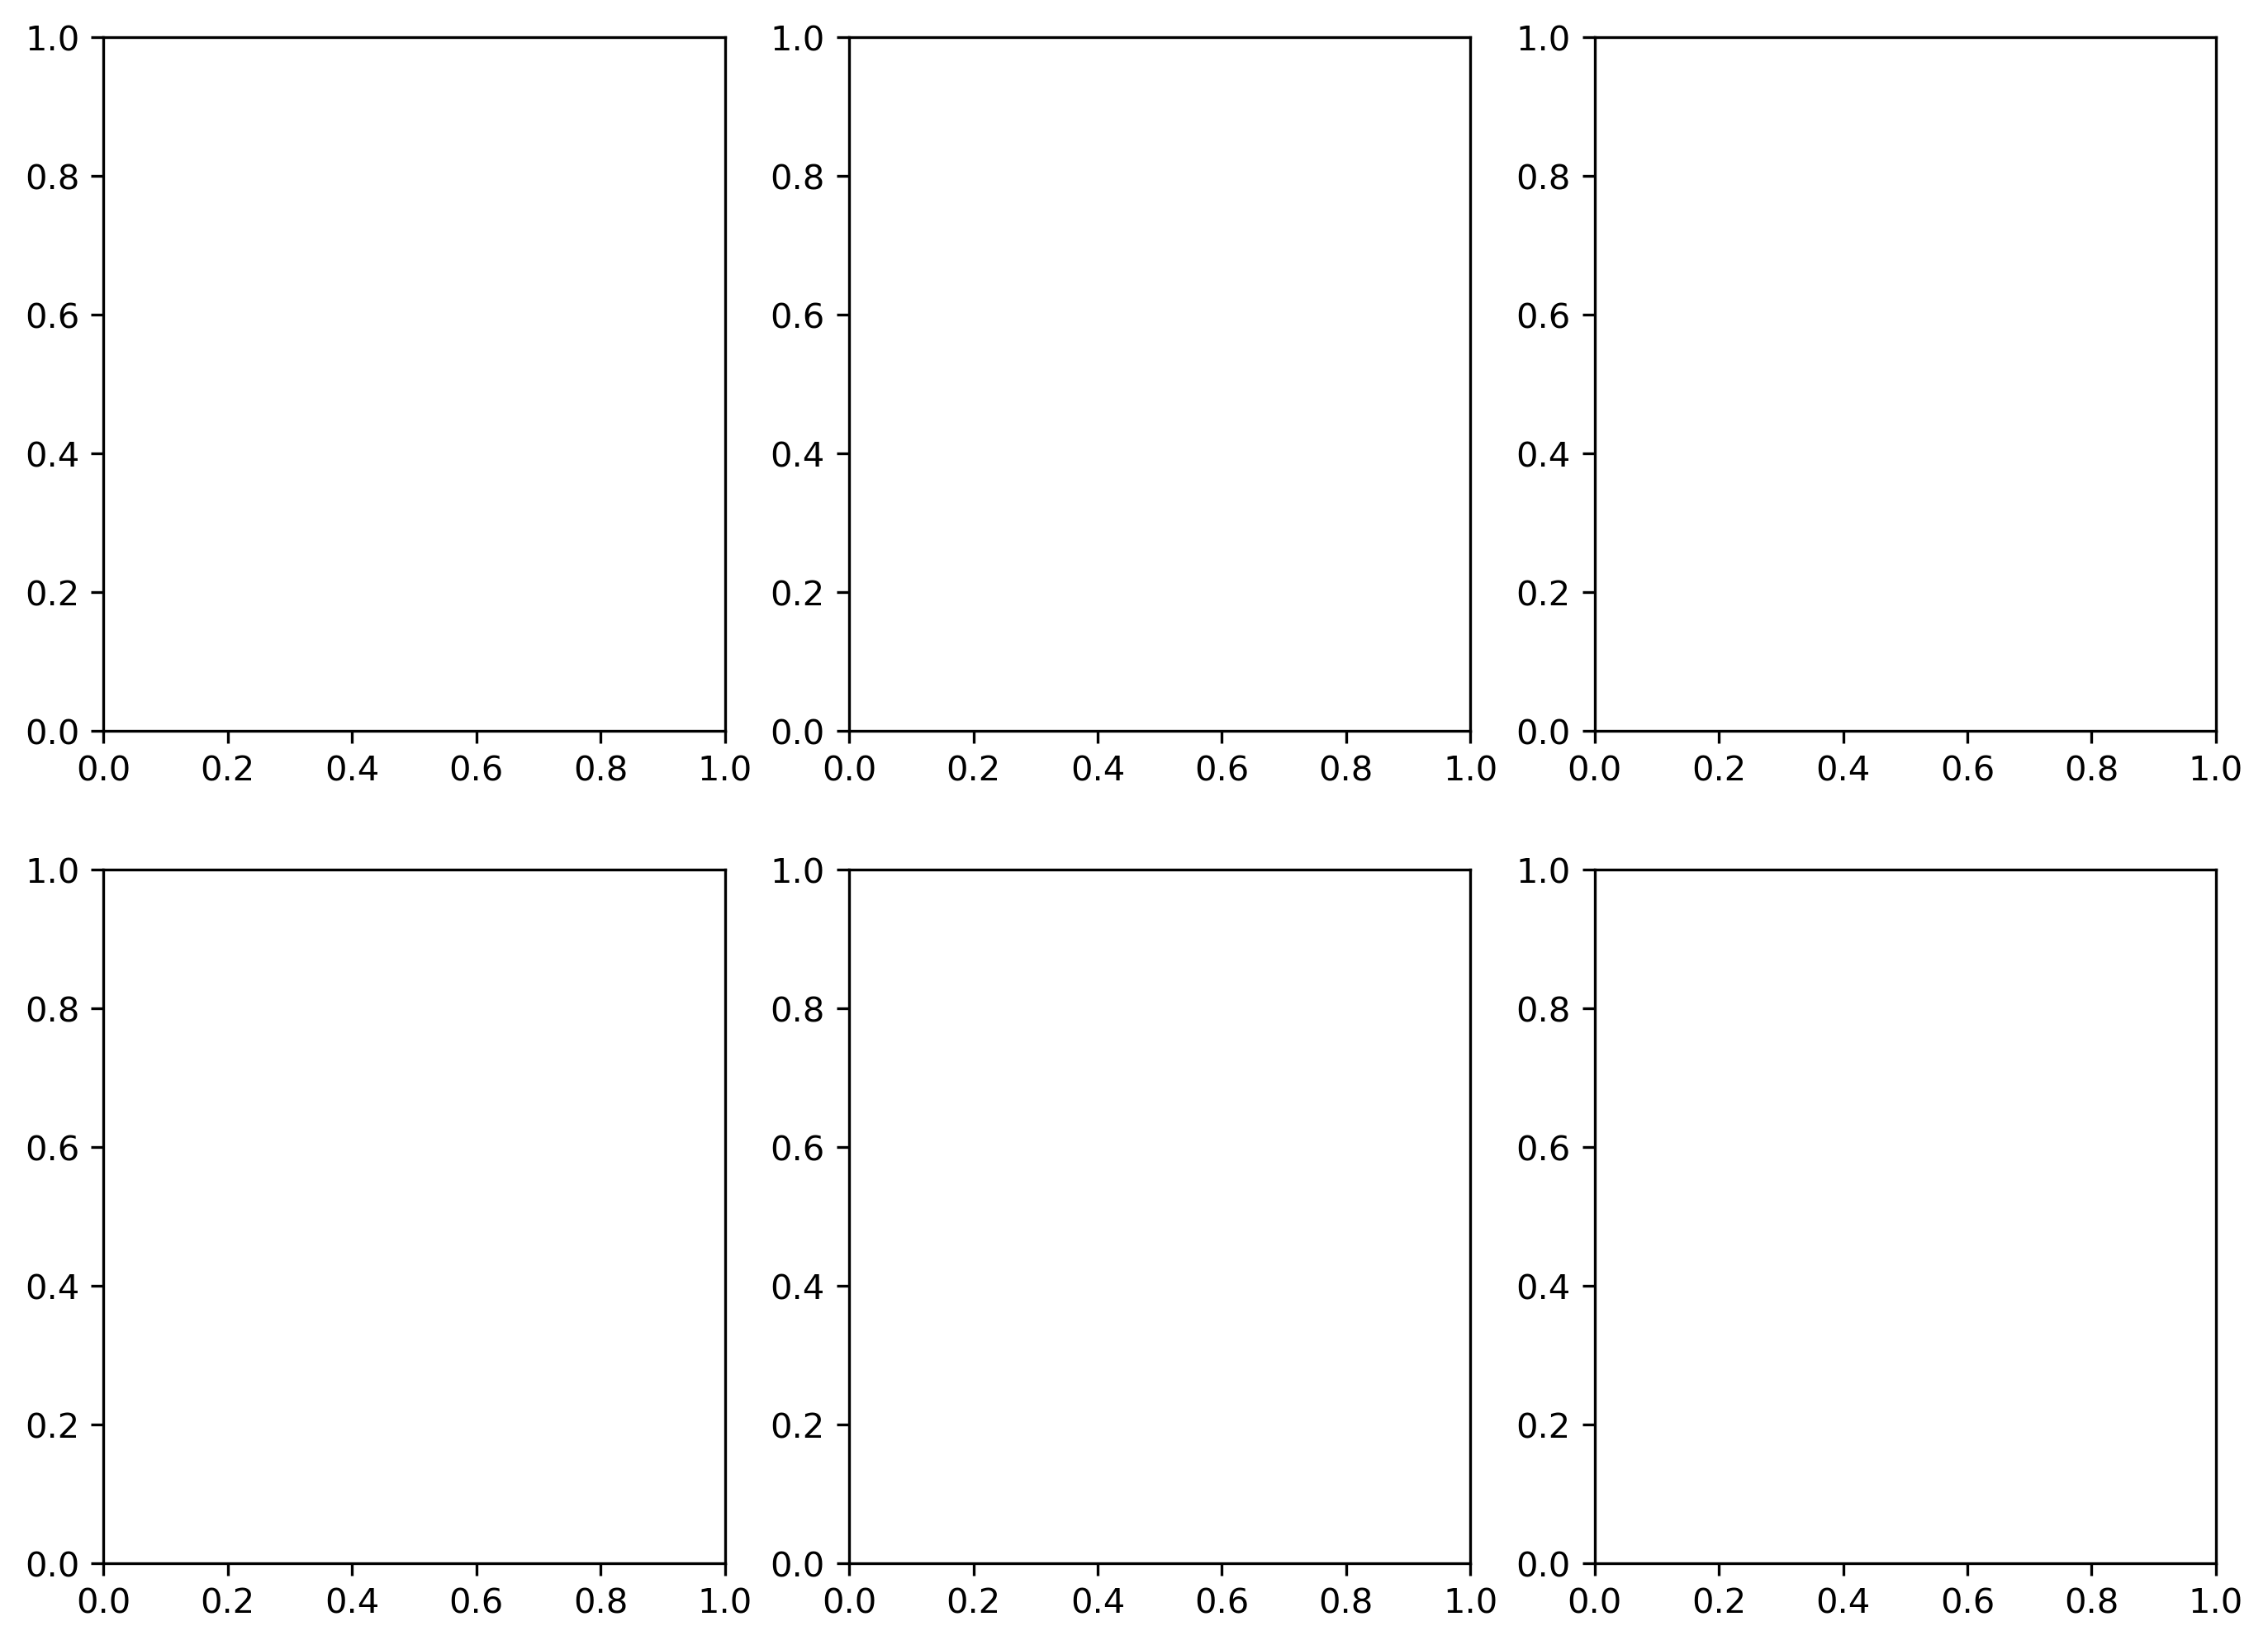

In [43]:

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

outcome_name_dict = {"ggi":"Female-Male Ratio","men":"Men Level","wom":"Women Level"}
hue_column = 'conti'
# ---------------- Prep ----------------

region_colors = {
    "Asia":"#e76254",  # Coral red
    "North America":"#7db782",  # Yellow-orange
    "Africa":"#f1975a",  # Light beige
    "South America":"#72c0c5",  # Pale cyan
    "Oceania":"#cf8dc5",  # Light blue
    "Europe":"#5f799a",  # Medium blue
    "Global":"#101c2c"   # Dark blue
}

# Split "outcome_var" -> indicator + outcome_core (e.g., "internet_ggi")
parts = df_all_res['outcome_var'].str.extract(r'^(internet|mobile)_(ggi|wom|men)$')
df_plot = df_all_res.copy()
df_plot['indicator'] = parts[0]
df_plot['outcome_core'] = parts[1]
df_plot = df_plot.dropna(subset=['indicator', 'outcome_core'])

# ---------------- Subplot Setup ----------------
fig, axes = plt.subplots(2, 3, figsize=(11, 8))
outcome_cores = ['ggi', 'wom', 'men']
indicators = ['internet', 'mobile']

for i, indicator in enumerate(indicators):
    for j, outcome in enumerate(outcome_cores):
        ax = axes[i, j]
        data = df_plot[(df_plot['indicator'] == indicator) & (df_plot['outcome_core'] == outcome)].copy()

        # --- scatterplot
        sns.scatterplot(
            data=data,
            x='pred_combined_with_CIS_align',
            y='pred_combined_with_CIS',
            hue=hue_column,
            palette=region_colors,
            s=25,
            alpha=1,
            ax=ax,
            legend=False if i + j > 0 else True
        )

        # --- 1:1 line
        ax.plot([-0.05, 1.05], [-0.05, 1.05], color='grey', linestyle='--', linewidth=1)
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)
        ax.set_aspect('equal', adjustable='box')

        # --- labels
        ax.set_xlabel("Aligned model predicted values")
        ax.set_ylabel("Original model predicted values")
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_title(f"{indicator.capitalize()} {outcome_name_dict.get(outcome, outcome)}", fontweight='bold')

        # --- pick top 5 by difference
        data['abs_diff'] = (data['pred_combined_with_CIS'] - data['pred_combined_with_CIS_align']).abs()
        top5 = data.nlargest(5, 'abs_diff')

        # --- annotate
        for _, row in top5.iterrows():
            ax.annotate(
                row['iso3'],
                (row['pred_combined_with_CIS_align'], row['pred_combined_with_CIS']),
                xytext=(3, 3), textcoords='offset points',
                fontsize=7, color='black'
            )
# remove legend from first subplot
axes[0, 0].legend_.remove()

# Adjust layout and legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title='Continent', loc='lower center', ncol=6, frameon=False)
plt.tight_layout(rect=[0, 0.05, 1, 1])

# save or show
# plt.savefig(params.FIG / "pred_vs_true_2x3_grid.png", bbox_inches='tight')
#plt.title("Predicted value comparison", fontsize=12, fontweight='bold', y=1.05,x=0.25)
plt.show()


## Trends 

In [44]:
def full_model_predictions(
    indicator,
    new_data,
    model_type,
    model_spec,
    outcome_var,
    align_year,
    model_coef
):
    """
    Generate predictions for new data using a trained model and estimate prediction error.

    Args:
        indicator (str): Indicator type ('internet' or 'mobile').
        new_data (pd.DataFrame): DataFrame containing new data for prediction.
        model_type (str): Model type (e.g., 'combined_with_CIS').
        model_spec (list): List of feature columns used in the model.
        outcome_var (str): Target variable name.
        align_year (int): Year for alignment/prediction.
        model_coef (pd.DataFrame): DataFrame containing model coefficients for error estimation.

    Returns:
        pd.DataFrame: DataFrame with columns ['iso3', 'year', 'outcome_var', 'model_type', 'pred', 'true', 'predicted_error'].
    """
    model_filename = f'{indicator}_{model_type}_{outcome_var}_full_model.pkl'
    model_filepath = params.dropbox_data_path.parent / f'models/OLS' / model_filename
    model = load_model(model_filepath)
    if model is None:
        raise ValueError("Model not found. Ensure the model has been trained and scaler saved.")

    predicted_results = pd.DataFrame(columns=["iso3", "year", 'outcome_var', 'model_type', 'pred', 'true', 'predicted_error'])
    new_data = new_data.dropna(subset=model_spec)
    new_data = new_data.loc[~new_data['iso3'].isin(params.sanction_countries)]
    X_new = preprocess_data(new_data[model_spec])
    X_new['const'] = 1
    X_new = X_new[['const'] + model_spec]
    y_pred_full = model.predict(X_new)

    predicted_results['iso3'] = new_data['iso3']
    predicted_results['outcome_var'] = outcome_var
    predicted_results['model_type'] = model_type
    predicted_results['pred'] = y_pred_full
    predicted_results["year"] = align_year
    predicted_results['true'] = [
        y if x == align_year else None
        for x, y in zip(new_data[f'{indicator}_year'], new_data[outcome_var])
    ]
    #predicted_results['predicted_error'] = X_new[model_spec] @ model_coef[model_spec].T

    return predicted_results


In [45]:
model_specs = {'online_with_CIS_align': fb_cols, 
                'offline_with_CIS_align': bg_cols, 
                "combined_with_CIS_align":fb_cols + bg_cols}

In [46]:

predicted_results = pd.DataFrame()
#coef= pd.read_csv(params.dropbox_data_path.parent / f'results/ols_predicted_by_year/{model_type}_country_model_error_estimation_betas.csv')
for indicator in ['internet','mobile']:
    for year in range(2015,2026):
        print(indicator,year)
        data_path = params.dropbox_data_path / f"combined_data/updated_ground_truth_and_fb/{indicator}"
        dataset = f"year_align/combined_multiple_years_no_missing_fb_aligned_{year}.csv"
        new_data = pd.read_csv(data_path/dataset)
        new_data['year']=new_data[f'align_year']-2015
       
        for outcome_var in [f'{indicator}_ggi', f'{indicator}_wom', f'{indicator}_men']:
            #for model_type in ['combined', 'combined_top_shaps_no_fertility']:
            model_type = 'combined_with_CIS_align'
            model_spec = model_specs[model_type]
            model_spec = align_model_spec(model_spec,model_type,outcome_var)
            print(outcome_var, model_spec)
            #model_coef = coef.loc[coef['model']==outcome_var]
            model_coef = None
            temp = full_model_predictions(indicator, new_data, model_type, model_spec,outcome_var,year,model_coef)
            predicted_results = pd.concat([predicted_results,temp], axis=0)

predicted_results['model_type'] = model_type
predicted_results['pred'] = [1 if x>1 else 0 if x<0 else x for x in predicted_results['pred']]
#predicted_results['predicted_error'] = [1 if x>1 else 0 if x<0 else x for x in predicted_results['predicted_error']]

internet 2015
internet_ggi ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_r']
internet_wom ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_wom']
internet_men ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_men']
internet 2016
internet_ggi ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_r']
internet_wom ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_wom']
internet_men ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_men']
internet 2017
internet_ggi ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_r']
internet_wom ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_wom']
internet_men ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_men']
internet 2018
internet_ggi ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_r']
internet_wom ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_wom']
internet_men ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_men']
internet 2019
internet_ggi ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_r']
internet_wom ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_wom']
internet_men ['hdi', 'gdi', 'g

internet_wom ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_wom']
internet_men ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_men']
mobile 2015
mobile_ggi ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_r']
mobile_wom ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_wom']
mobile_men ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_men']
mobile 2016
mobile_ggi ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_r']
mobile_wom ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_wom']
mobile_men ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_men']
mobile 2017
mobile_ggi ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_r']
mobile_wom ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_wom']
mobile_men ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_men']
mobile 2018
mobile_ggi ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_r']
mobile_wom ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_wom']
mobile_men ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_men']
mobile 2019
mobile_ggi ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_r']
m

mobile_wom ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_wom']
mobile_men ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_men']
mobile 2022
mobile_ggi ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_r']
mobile_wom ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_wom']
mobile_men ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_men']
mobile 2023
mobile_ggi ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_r']
mobile_wom ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_wom']
mobile_men ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_men']
mobile 2024
mobile_ggi ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_r']
mobile_wom ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_wom']
mobile_men ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_men']
mobile 2025
mobile_ggi ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_r']
mobile_wom ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_wom']
mobile_men ['hdi', 'gdi', 'gdp_pcap', 'year', 'fb_18_999_men']


In [47]:
predicted_results

,iso3,year,outcome_var,model_type,pred,true,predicted_error
0,ABW,2015,internet_ggi,combined_with_CIS_align,0.843795,NaN,NaN
1,AFG,2015,internet_ggi,combined_with_CIS_align,0.169927,NaN,NaN
2,AGO,2015,internet_ggi,combined_with_CIS_align,0.584424,0.468482,NaN
3,ALB,2015,internet_ggi,combined_with_CIS_align,0.782979,NaN,NaN
4,AND,2015,internet_ggi,combined_with_CIS_align,0.932539,NaN,NaN
...,...,...,...,...,...,...,...
258,ZMB,2025,mobile_men,combined_with_CIS_align,0.798950,NaN,NaN
259,ZMB,2025,mobile_men,combined_with_CIS_align,0.798950,NaN,NaN
260,ZWE,2025,mobile_men,combined_with_CIS_align,0.780677,NaN,NaN
261,ZWE,2025,mobile_men,combined_with_CIS_align,0.780677,NaN,NaN


In [48]:
current_year = 2025 
current_month = 7
dropbox_fb_path = (params.EXTERNAL / 'pipeline')
df_fb_data = pd.read_csv(dropbox_fb_path / f'preprocessed/national/fb_national_sd_rolling_std_{current_year}{current_month:02d}.csv')


fb_result_path = params.dropbox_result_path/f'{model_type}'
for current_year in range(2015, 2026):
    for current_month in range(1,13):
        if (current_month>=2) and (current_year)<2019:
            continue
        else:
            date = f'{current_year}-{str(current_month).zfill(2)}'
            if not os.path.isfile(fb_result_path / f'{date}.csv'):

                fb_cols = params.fb_vars_18_plus
                df_result = pd.DataFrame(columns=['gid_0', 'outcome', 'true', 'predicted', 'date'])
            
            
                for indicator in ['internet', 'mobile']:
                    for outcome_var in [f'{indicator}_ggi',f'{indicator}_wom', f'{indicator}_men']:
    
                        #print(outcome_var)
                        # read file based on year
                        df_model = pd.read_csv(dropbox_fb_path / f'model_fit/national/data/{indicator}/combined_multiple_years_no_missing_fb_aligned_{round(current_year)}.csv')
            
                        if current_year >= 2019:
                            for col in fb_cols:
                                if col in df_model.columns:
                                    df_model.drop(columns=col, inplace=True)
                            df_fb_data_selected = df_fb_data.loc[(df_fb_data['year'] == current_year) & (df_fb_data['month'] == current_month)]
                            df_model = df_model.merge(df_fb_data_selected, left_on=['iso3', 'align_year'], right_on=['iso3', 'year'], how='left')
                        
                        model_spec = align_model_spec(model_specs[model_type],model_type,outcome_var)
                        print(outcome_var, model_spec)

                        #df_model.drop(columns=[f'{indicator}_year'], inplace=True)
                        
                        df_model['year']=df_model['align_year']-2015
                        df_model = df_model.dropna(subset=model_spec)
            
                            # load the model
                        model_filename = f'{indicator}_{model_type}_{outcome_var}_full_model.pkl' 
                        model_filepath = params.dropbox_data_path.parent / f'models/OLS' / model_filename
                        
                        temp = pd.DataFrame(columns=['gid_0','outcome','true', 'predicted','date'])
                        model = load_model(model_filepath)
            
                        df_model = df_model.groupby(['iso3']).mean(numeric_only=True).reset_index()  # some countries have multiple entries but the results are the same
                        
                        df_model.drop(columns=['align_year'],inplace=True)
                        countries = df_model['iso3'].tolist()
                        df_model['const']=1
                        X = df_model[['const']+model_spec]
                        y_pred = model.predict(X)
            
                        for ind in range(len(y_pred)):
                            true_value = df_model.loc[(df_model[f'{indicator}_year'] == current_year) & (df_model[f'iso3'] == countries[ind]), outcome_var]
                            true_value = true_value.values[0] if len(true_value) > 0 else None
                            temp.loc[len(temp), :] = [countries[ind],outcome_var, true_value, y_pred[ind], date]
            
            
                        # now get the predicted errors
                        #df_error_beta = pd.read_csv(params.dropbox_data_path.parent / f'results/ols_predicted_by_year/{model_type}_country_model_error_estimation_betas.csv')
                        #coefficients = df_error_beta.loc[(df_error_beta['model'] == outcome_var)].values[0][3:]
            
                        #model_spec = df_error_beta.columns.to_list()[3:]
                        #df_model.rename(columns={'align_year':'year'}, inplace=True)
                        
                        #temp['predicted_error'] = df_model[model_spec] @ coefficients
            
            
                        df_result = pd.concat([df_result, temp], axis=0)
                        #print(df_result['outcome'].unique())
                
                df_result['predicted_error']=0
                df_result = df_result[['gid_0', 'outcome', 'predicted', 'predicted_error', 'date']]
            
                df_result['outcome'] = df_result['outcome'].str.replace('ggi', 'fm_ratio')
                for col in ['predicted', 'predicted_error']:
                    # only three decimal places
                    df_result[col] = df_result[col].apply(lambda x: round(x, 3))
            
                df_result['outcome'].replace({'mobile_wom': 'mobile_women', 'internet_wom': 'internet_women'}, inplace=True)
                df_result['predicted'] = df_result['predicted'].apply(lambda x: min(x, 1))
                df_result['predicted_error'] = df_result['predicted_error'].apply(lambda x: min(x, 1))
                
                df_result['predicted'] = df_result['predicted'].apply(lambda x: max(x, 0))
                df_result['predicted_error'] = df_result['predicted_error'].apply(lambda x: max(x, 0))
                
                df_result = df_result.loc[~df_result['gid_0'].isin(params.sanction_countries)]

                if not os.path.isdir(fb_result_path):
                    os.makedirs(fb_result_path, exist_ok=True)
                if current_year>=2019:

                    df_result.to_csv(fb_result_path / f'{date}.csv', index=False)
                else:
                    df_result.to_csv(fb_result_path / f'{round(current_year)}.csv', index=False)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/valler/Python/RA/Gender_Inequality/dgg_national/data/external/pipeline/preprocessed/national/fb_national_sd_rolling_std_202507.csv'

In [49]:
dropbox_fb_path

PosixPath('/Users/valler/Python/RA/Gender_Inequality/dgg_national/data/external/pipeline')

In [50]:

# load data
dropbox_fb_path = params.dropbox_result_path/ f'{model_type}' #params.dropbox_result_path / f'{model_type}'

df_all_res = pd.DataFrame()
for file in dropbox_fb_path.glob("*.csv"):
    print(file)
    # Read the CSV file and concatenate it to df_all_res
    df = pd.read_csv(file)
    df['year'] = df['date'].values[0].split('-')[0]  # Extract year from filename
    df_all_res = pd.concat([df_all_res, df], ignore_index=True)
df_all_res = df_all_res.groupby(['outcome','gid_0','year']).agg({'predicted': 'mean', 'predicted_error': 'mean'}).reset_index()

df_all_res = utils.mark_regions(df_all_res,'gid_0')
df_all_res.drop(df_all_res.loc[df_all_res['gid_0']=='YEM'].index, inplace=True)


facet_label = 'region'
indicator='internet'
outcome_var = 'fm_ratio'

/Users/valler/Python/RA/Gender_Inequality/dgg_national/data/external/national/data_refresh/new_national_pipeline_files/results/pred_by_year_and_month/combined_with_CIS_align/2020-02.csv
/Users/valler/Python/RA/Gender_Inequality/dgg_national/data/external/national/data_refresh/new_national_pipeline_files/results/pred_by_year_and_month/combined_with_CIS_align/2022-07.csv
/Users/valler/Python/RA/Gender_Inequality/dgg_national/data/external/national/data_refresh/new_national_pipeline_files/results/pred_by_year_and_month/combined_with_CIS_align/2022-12.csv
/Users/valler/Python/RA/Gender_Inequality/dgg_national/data/external/national/data_refresh/new_national_pipeline_files/results/pred_by_year_and_month/combined_with_CIS_align/2022-06.csv
/Users/valler/Python/RA/Gender_Inequality/dgg_national/data/external/national/data_refresh/new_national_pipeline_files/results/pred_by_year_and_month/combined_with_CIS_align/2020-03.csv
/Users/valler/Python/RA/Gender_Inequality/dgg_national/data/external/n

/Users/valler/Python/RA/Gender_Inequality/dgg_national/data/external/national/data_refresh/new_national_pipeline_files/results/pred_by_year_and_month/combined_with_CIS_align/2022-09.csv
/Users/valler/Python/RA/Gender_Inequality/dgg_national/data/external/national/data_refresh/new_national_pipeline_files/results/pred_by_year_and_month/combined_with_CIS_align/2025-02.csv
/Users/valler/Python/RA/Gender_Inequality/dgg_national/data/external/national/data_refresh/new_national_pipeline_files/results/pred_by_year_and_month/combined_with_CIS_align/2025-03.csv


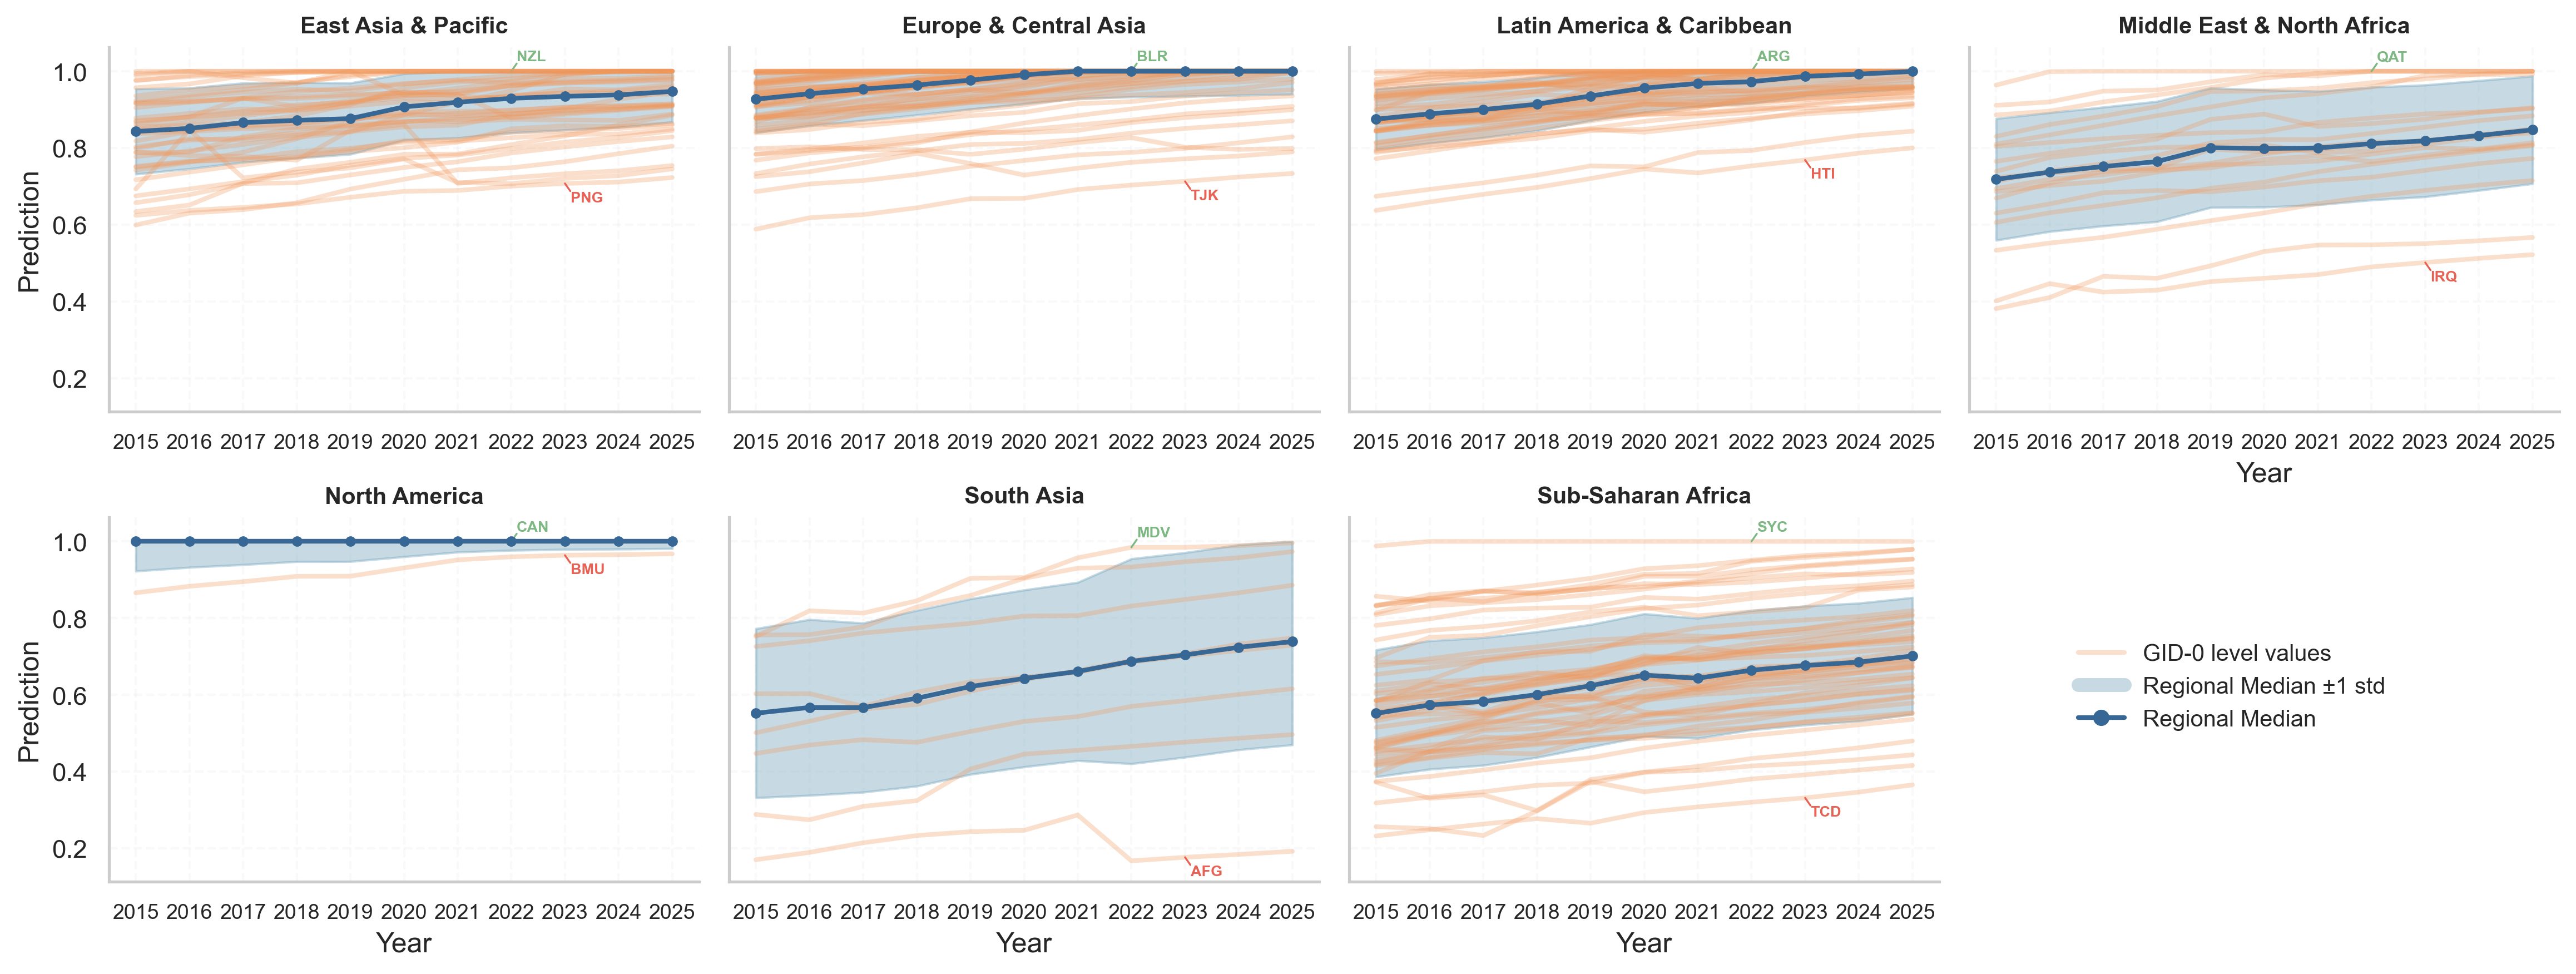

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D
import numpy as np

# Ensure year is numeric
df_all_res['year'] = pd.to_numeric(df_all_res['year'])
df_all_res = df_all_res[df_all_res['outcome'] == f'{indicator}_{outcome_var}']

# Set seaborn style
sns.set(style="whitegrid")

# Compute regional median and std (for ±1 std shading)


# Compute median, std, and count per region and year
region_stats = df_all_res.groupby([facet_label, 'year'])['predicted'].agg(
    median='median',
    std='std',
    n='count'
).reset_index()
''' 
# Compute 95% CI around the median using std/sqrt(n)
region_stats['ci95'] = 1.96 * (region_stats['std'] / np.sqrt(region_stats['n']))
region_stats['lower'] = region_stats['median'] - region_stats['ci95']
region_stats['upper'] = region_stats['median'] + region_stats['ci95']
'''
region_stats['lower'] =[x if x<=1 else 1 for x in region_stats['median'] - region_stats['std']]
region_stats['upper'] =[x if x<=1 else 1 for x in region_stats['median'] + region_stats['std']]

# Set up FacetGrid
g = sns.FacetGrid(df_all_res, col=facet_label, col_wrap=4, height=3, aspect=1.3)

# Plot each region

for ax, (region_name, region_data) in zip(g.axes.flat, df_all_res.groupby(facet_label)):
    gid_legend_handles = []

    # Compute avg prediction per gid_0
    gid_avg = region_data.groupby('gid_0')['predicted'].mean()
    highest_gid = gid_avg.idxmax()
    lowest_gid = gid_avg.idxmin()

    for gid, group in region_data.groupby('gid_0'):
        group = group.sort_values('year')
        line, = ax.plot(
            group['year'],
            group['predicted'],
            color='#f1975a',
            alpha=0.3,
            linewidth=2,
            label='GID-0 level values'  # add gid label for legend
        )

        if len(gid_legend_handles) < 1:
            gid_legend_handles.append(line)

        # Annotation for highest avg gid_0 (green, near year 2022)
        if gid == highest_gid:
            near_2022 = group.loc[group['year'] == 2022]
            if not near_2022.empty:
                y_val = near_2022['predicted'].values[0]
                ax.text(
                    2022.1,
                    y_val + 0.02,
                    gid,
                    fontsize=6.5,
                    color='#7db782',
                    va='bottom',
                    ha='left',
                    fontweight='bold'
                )
                # Draw short line from trend to label
                ax.plot(
                    [2022, 2022.1],
                    [y_val, y_val + 0.02],
                    color='#7db782',
                    linewidth=0.8
                )

        # Annotation for lowest avg gid_0 (red, near year 2023)
        if gid == lowest_gid:
            near_2023 = group.loc[group['year'] == 2023]
            if not near_2023.empty:
                y_val = near_2023['predicted'].values[0]
                ax.text(
                    2023.1,
                    y_val - 0.02,
                    gid,
                    fontsize=6.5,
                    color='#e76254',
                    va='top',
                    ha='left',
                    fontweight='bold'
                )
                # Draw short line from trend to label
                ax.plot(
                    [2023, 2023.1],
                    [y_val, y_val - 0.02],
                    color='#e76254',
                    linewidth=0.8
                )

    # Regional stats
    reg = region_stats[region_stats[facet_label] == region_name]

    ax.fill_between(
        reg['year'],
        reg['lower'],
        reg['upper'],
        color='#73a4bc',
        alpha=0.4,
        label='95% CI'
    )

    ax.plot(
        reg['year'],
        reg['median'],
        color='#376795',
        linewidth=2,
        marker='o',
        markersize=3.5,
        linestyle='-',
        label='Regional Median'
    )

    ax.set_title(region_name, fontsize=10, fontweight='bold')
    ax.set_xlabel("Year")
    ax.set_ylabel("Prediction")
    ax.grid(True, linestyle='--', alpha=0.1)

    all_years = sorted(region_data['year'].unique())
    ax.set_xticks(all_years)
    ax.set_xticklabels(all_years, fontsize=9)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x)}"))
    ax.tick_params(axis='x', which='both', labelbottom=True)

# Build the legend handles (same as before)
legend_elements = gid_legend_handles + [
    Line2D([0], [0], color='#73a4bc', lw=6, alpha=0.4, label='Regional Median ±1 std'),
    Line2D([0], [0], color='#376795', lw=2, marker='o', label='Regional Median')
]

# Add global legend to the right of the figure
g.fig.legend(
    handles=legend_elements,
    loc='center left',
    bbox_to_anchor=(0.8, 0.3),  # Right outside the grid
    borderaxespad=0,
    frameon=False,
    title='',
    fontsize='small'
)

plt.tight_layout()


In [52]:
# merge the plots together for the model performance figure